(733, 17)
(183, 17)


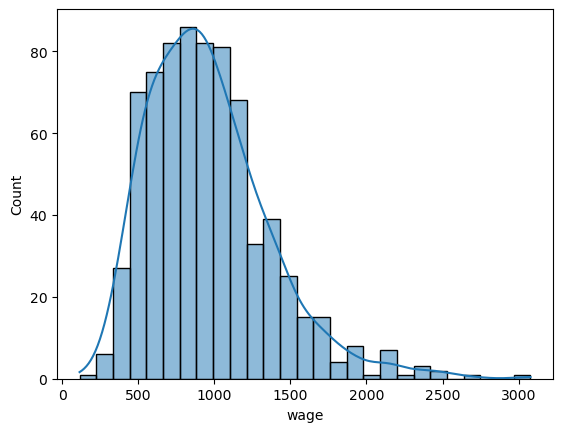

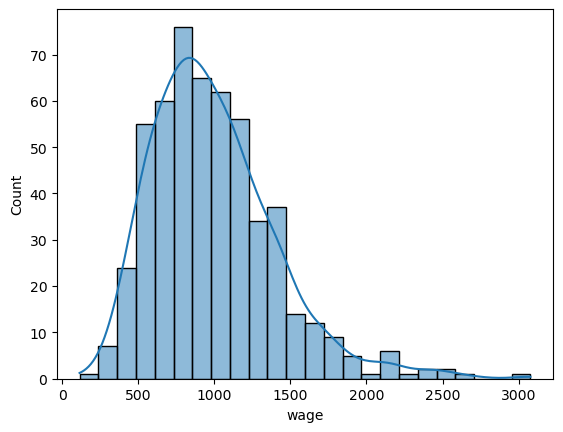

(531, 17)
(124, 17)


In [1]:
# ================================================================================
# Splitting training and test sets
# ================================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

data=pd.read_csv('WAGE2_2025_abridged.csv')

state=530088808+540338216+540527739+530800484+530356855 # replace this number with the sum of the student IDs for the members of your group

train = data.sample(frac=0.8, random_state=state)
test = data[data.index.isin(train.index)==False].copy() # Only for prediction

train=train.reset_index(drop=True)
test=test.reset_index(drop=True)
print(train.shape)
print(test.shape)
sns.histplot(train['wage'],kde=True)
plt.show()
#Check null values
train.isnull().any()
test.isnull().any()
#Drop null values
train=train.dropna()
test=test.dropna()
sns.histplot(train['wage'],kde=True)
plt.show()
print(train.shape) #training data original: 733, after cleaning = 531, change = 202
print(test.shape) #testing data original: 183, after cleaning = 124, change = 59

**3. Problem formulation**

Construct different multiple linear regression (MLR) models on the training data, consisting of 733 workers to examine the relationship between some of the independent variables, with years of experience and years of education as the base, and the monthly wage. Test the models' accuracy on the test data including of 183 workers.

There are a total of 15 independent variables in the dataset, including experience and education. Identify missing variables that potentially cause omitted variable bias (OVB) and incorporate them into the base model. Evaluate the fit of the new model and check for multicollinearity

Consider other potential methods of model formulations and independent variables that could improve the model's fit and predictive accuracy.

**4. Data cleaning**

We consider two approaches to data cleaning. The first one is to drop datas consist of null values only to the extent of dependent variables that we decide to use in the model formulation. This way, minimum number of data will be removed, which both helps remain as much data as possible, but still ensure consistency and integrity in the analysis. However, we find it challenging to figure out which dependent variables will be used in the formulation in the first stage. Therefore we come up with the second approach of dropping all datas that one or more of the dependent variables are null. This way, 202 datas of the train dataset and 59 datas of the test data set were removed. We acknowledge that reducing the size of the dataset significantly may impact its representativeness of the population, however as a trade-off, it would also prevent biases or inaccuracies in the regression results that the original one may have caused. Hence, the analysis ensures that model outputs are based fully on complete data, enhancing reliability of the insights into the relationships between these variables. For future research purposes, additional and complete data connection, together with research and analysis should be conducted to give timely and optimal findings of the study.

In [2]:
train.head()


,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
0,962,40,85,41,10,15,16,38,1,0,0,1,1,2.0,9.0,12.0,6.869014
2,894,40,104,35,18,7,10,35,1,0,1,0,7,8.0,9.0,8.0,6.795706
3,1250,40,92,42,16,10,11,32,0,0,1,1,1,1.0,12.0,10.0,7.130899
4,550,46,95,44,12,18,15,35,1,0,0,1,1,1.0,12.0,11.0,6.309918
5,600,40,114,36,16,5,4,30,1,0,1,1,2,1.0,12.0,12.0,6.396930


In [3]:
test.head()

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
1,1318,38,119,24,16,7,2,28,1,0,0,1,3,1.0,10.0,10.0,7.183871
2,1792,40,118,47,16,9,9,34,1,0,0,1,1,1.0,12.0,12.0,7.491087
7,1274,40,106,35,13,11,12,31,1,0,0,1,0,1.0,15.0,12.0,7.149917
8,692,40,108,48,12,21,11,38,1,0,0,1,3,1.0,8.0,7.0,6.539586
10,808,60,109,47,13,14,12,38,1,0,0,1,2,2.0,12.0,10.0,6.694562


In [4]:
#EDA after cleaning
train.describe().round(2)


,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
count,531.00,531.00,531.00,531.00,531.00,531.00,531.00,531.00,531.0,531.00,531.00,531.00,531.00,531.00,531.00,531.00,531.00
mean,995.62,44.08,103.01,36.34,13.73,11.41,6.98,33.00,0.9,0.08,0.33,0.72,2.86,2.20,10.89,10.27,6.82
std,409.45,7.25,14.77,7.56,2.25,4.26,4.96,3.11,0.3,0.26,0.47,0.45,2.26,1.51,2.80,3.30,0.41
min,115.00,25.00,54.00,13.00,9.00,1.00,0.00,28.00,0.0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,4.74
25%,700.00,40.00,95.00,32.00,12.00,8.00,2.00,30.00,1.0,0.00,0.00,0.00,1.00,1.00,9.00,8.00,6.55
50%,929.00,40.00,104.00,37.00,13.00,11.00,7.00,33.00,1.0,0.00,0.00,1.00,2.00,2.00,12.00,11.00,6.83
75%,1201.50,48.00,113.00,42.00,16.00,15.00,10.00,36.00,1.0,0.00,1.00,1.00,4.00,3.00,12.00,12.00,7.09
max,3078.00,80.00,145.00,56.00,18.00,22.00,22.00,38.00,1.0,1.00,1.00,1.00,14.00,10.00,18.00,18.00,8.03


In [5]:
test.describe().round(2)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
count,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00
mean,957.16,44.08,100.48,35.73,13.55,11.23,7.94,32.84,0.90,0.09,0.27,0.70,2.69,2.02,10.54,10.26,6.78
std,401.36,6.83,14.22,7.55,2.16,4.23,5.15,2.89,0.31,0.29,0.44,0.46,2.08,1.29,2.94,3.25,0.43
min,200.00,32.00,66.00,19.00,9.00,1.00,0.00,28.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,5.30
25%,687.25,40.00,91.00,30.00,12.00,8.00,3.00,30.00,1.00,0.00,0.00,0.00,1.00,1.00,8.00,8.00,6.53
50%,943.50,40.00,99.50,36.50,12.00,11.00,8.00,32.50,1.00,0.00,0.00,1.00,2.00,2.00,12.00,10.00,6.85
75%,1154.25,48.00,109.25,41.00,16.00,14.25,12.00,35.00,1.00,0.00,1.00,1.00,3.00,2.00,12.00,12.00,7.05
max,2771.00,70.00,134.00,49.00,18.00,21.00,20.00,38.00,1.00,1.00,1.00,1.00,13.00,7.00,18.00,18.00,7.93


After cleaning the data by removing all data including null values, we retained 530 observations for the training data and 125 observations for the test data. To gain insights into our objectives to achieve our goals of examining the relationship between years of education, years of experience and monthly wage, and to build an optimal model to forecast income, and to determine whether education or experience should be focused on for predicting income. 

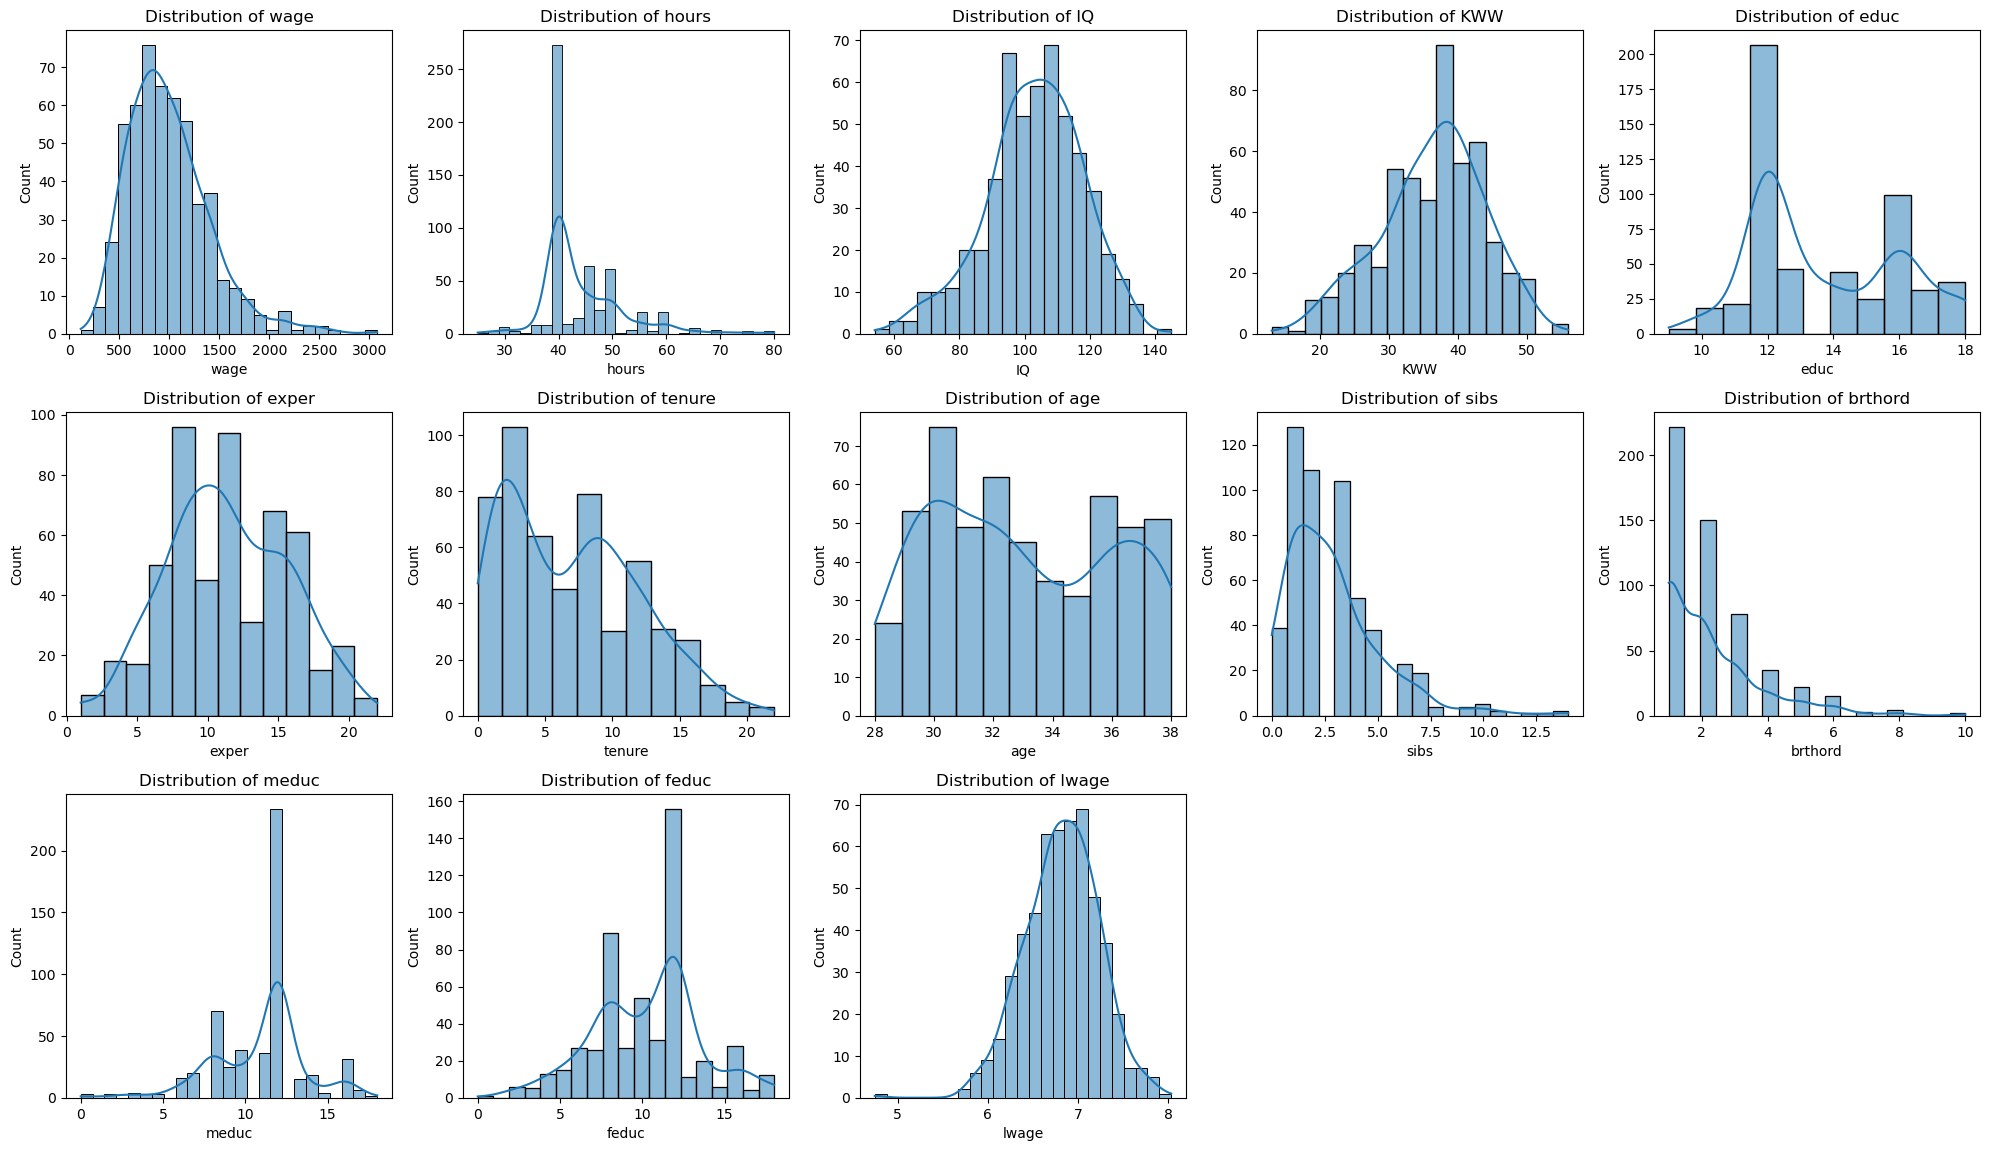

In [6]:
#Distribution of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.histplot(train[var],kde=True,ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

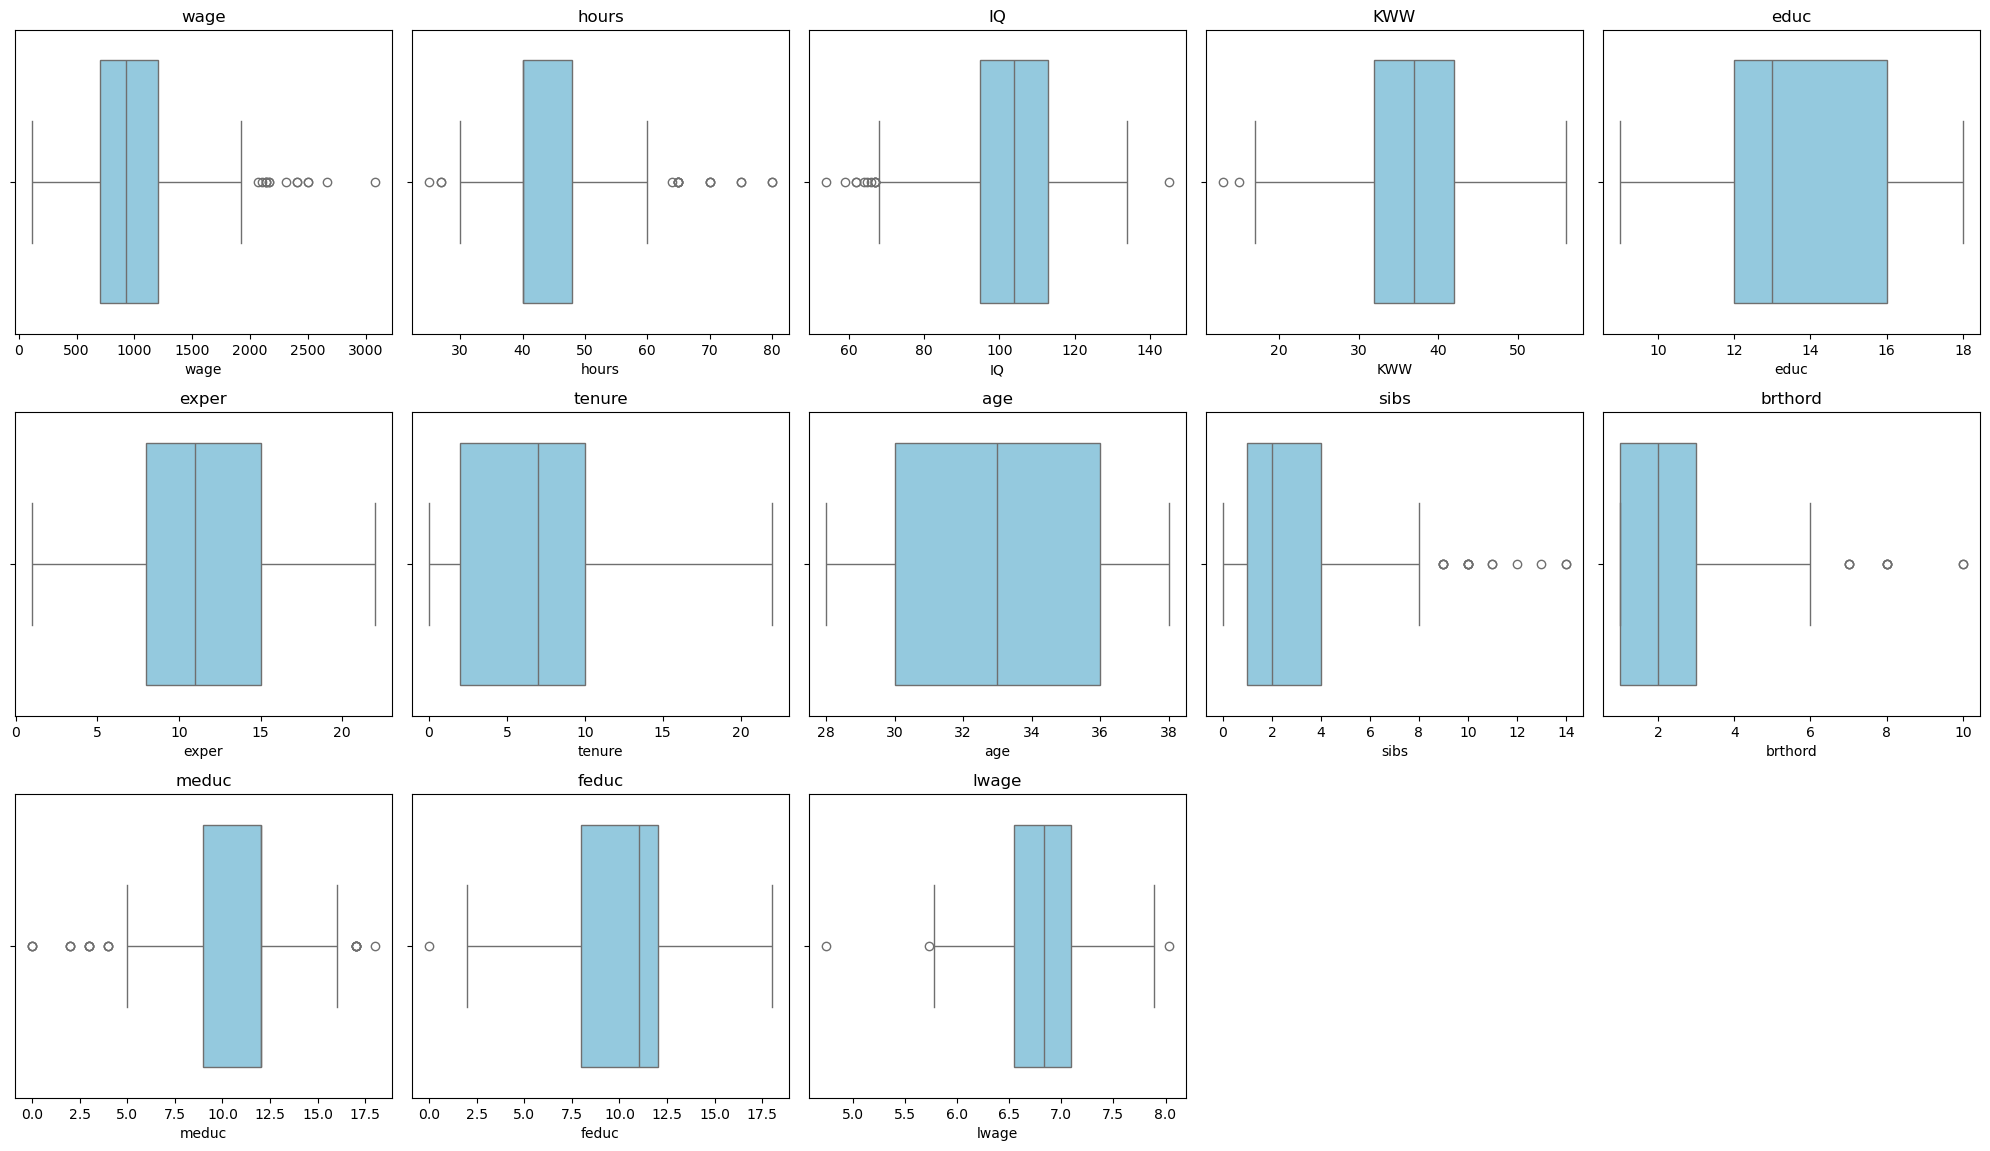

In [7]:
#boxplots of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.boxplot(x=train[var],ax=axes[i],color='skyblue')
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel('')
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The distribution of wage skewed heavily to the right, indicating the distribution of most individuals earning around the lower range, and a few high-earners that push the tail. Looking at the histogram of lwage where approximately normal distribution incurs, this might suggest the use of lwage for normalisation in future moelling stages. 

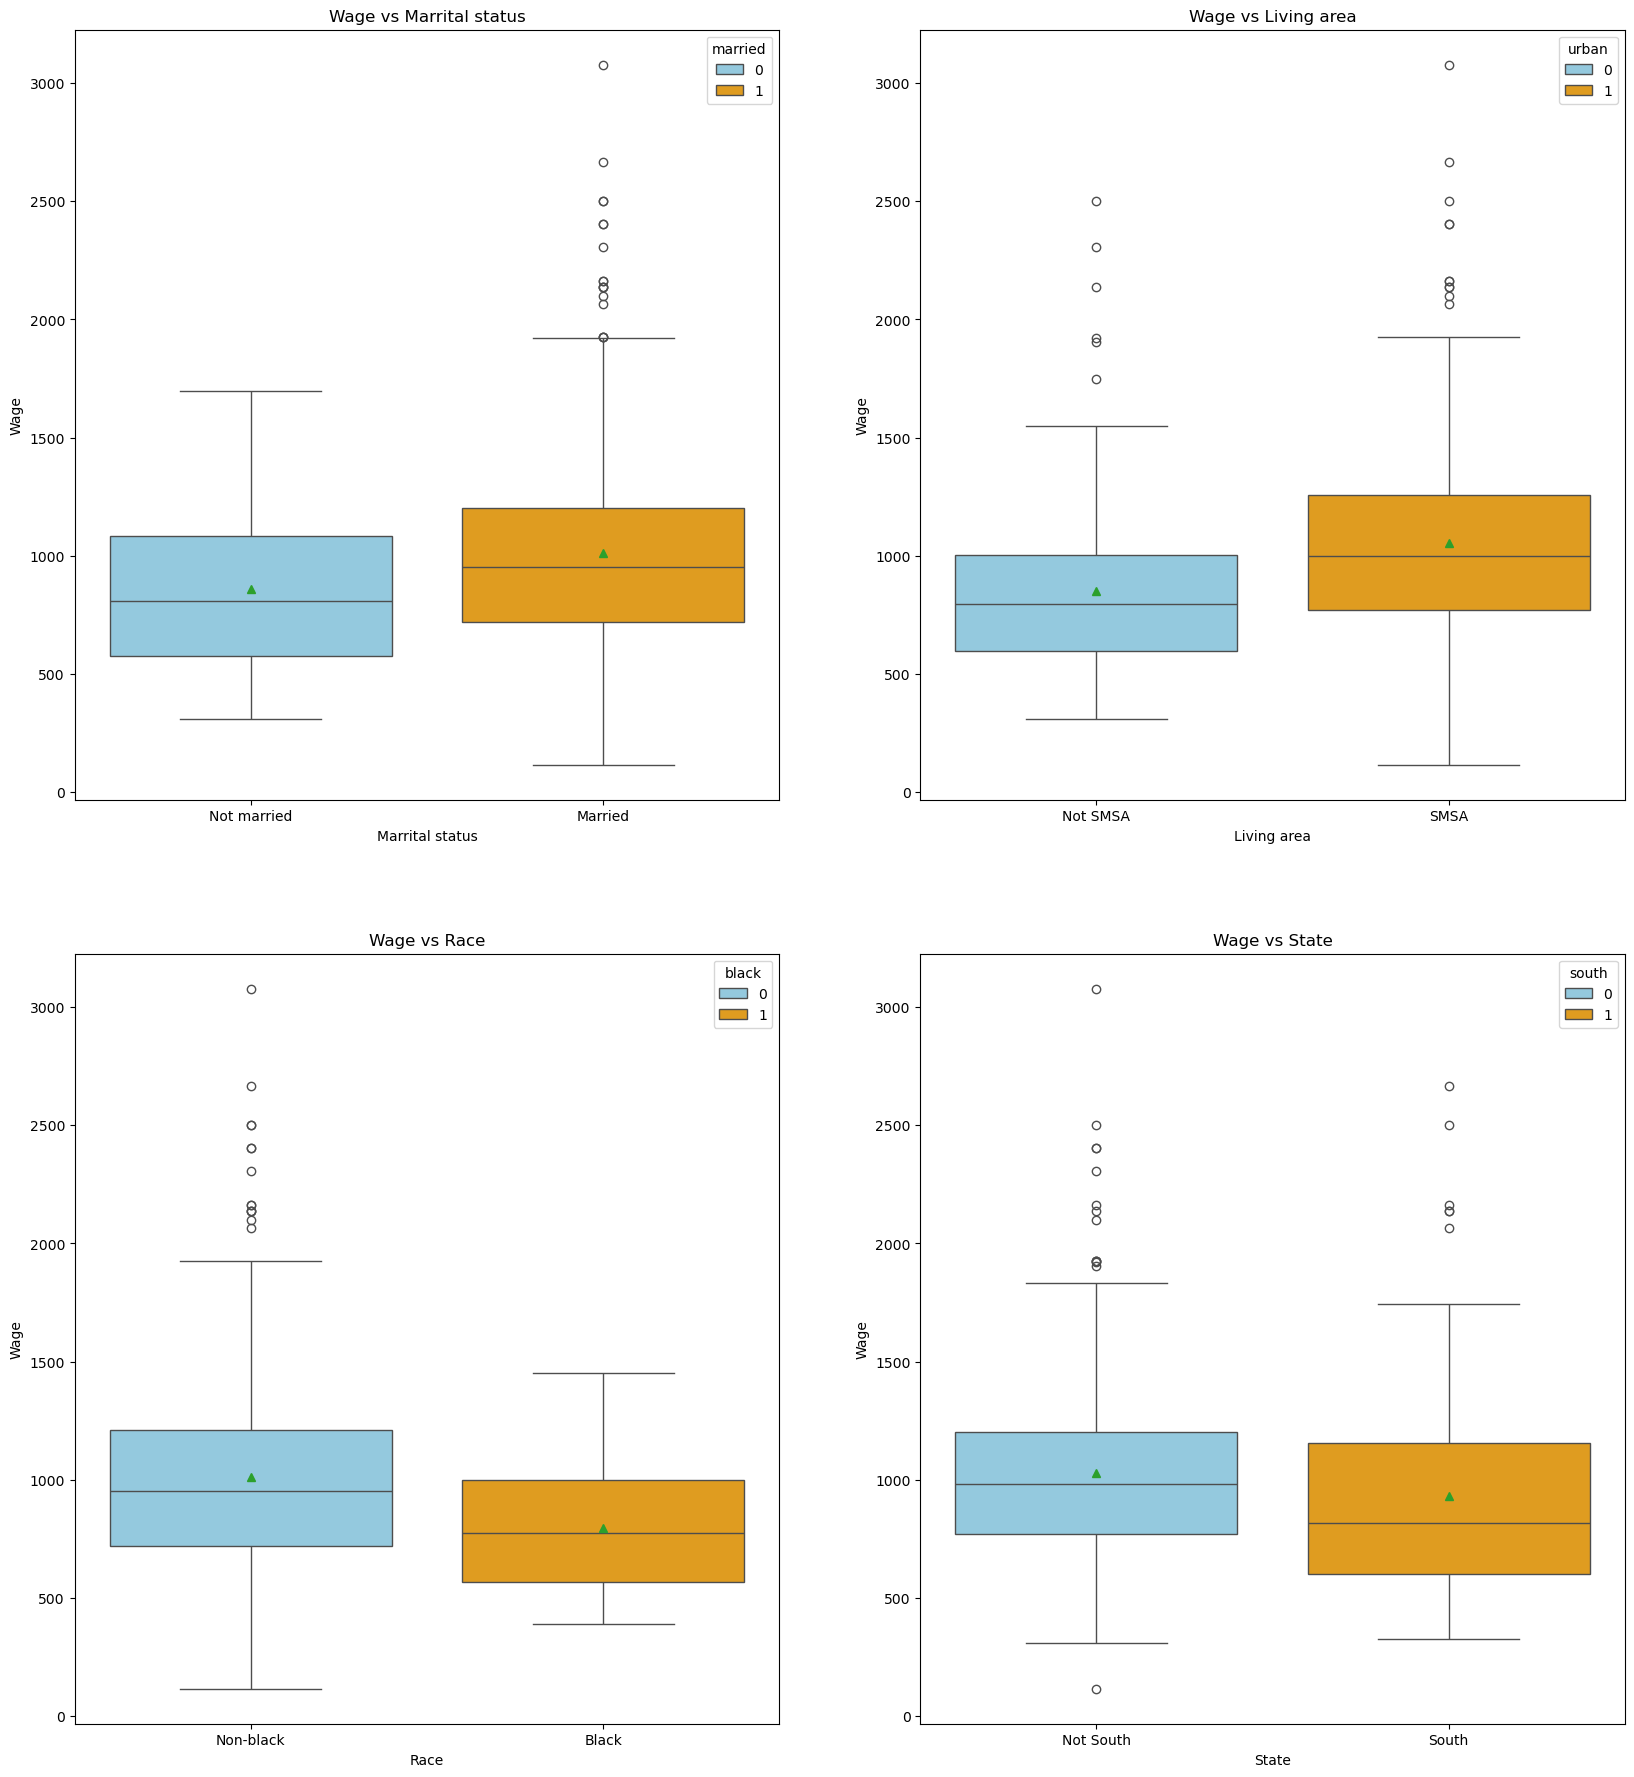

In [8]:
#side-by-side boxplots of wages vs categorical variabes
fig,ax=plt.subplots(2,2,figsize=(20,22))
sns.boxplot(x=train['married'],y=train['wage'],hue=train['married'],palette=['skyblue','orange'],ax=ax[0,0],showmeans=True)
ax[0,0].set_title('Wage vs Marrital status')
ax[0,0].set_xlabel('Marrital status')
ax[0,0].set_ylabel('Wage')
ax[0,0].set_xticks([0,1],['Not married','Married'])
sns.boxplot(x=train['urban'],y=train['wage'],hue=train['urban'],palette=['skyblue','orange'],ax=ax[0,1],showmeans=True)
ax[0,1].set_title('Wage vs Living area')
ax[0,1].set_xlabel('Living area')
ax[0,1].set_ylabel('Wage')
ax[0,1].set_xticks([0,1],['Not SMSA','SMSA'])
sns.boxplot(x=train['black'],y=train['wage'],hue=train['black'],palette=['skyblue','orange'],ax=ax[1,0],showmeans=True)
ax[1,0].set_title('Wage vs Race')
ax[1,0].set_xlabel('Race')
ax[1,0].set_ylabel('Wage')
ax[1,0].set_xticks([0,1],['Non-black','Black'])
sns.boxplot(x=train['south'],y=train['wage'],hue=train['south'],palette=['skyblue','orange'],ax=ax[1,1],showmeans=True)
ax[1,1].set_title('Wage vs State')
ax[1,1].set_xlabel('State')
ax[1,1].set_ylabel('Wage')
ax[1,1].set_xticks([0,1],['Not South','South'])
plt.show()

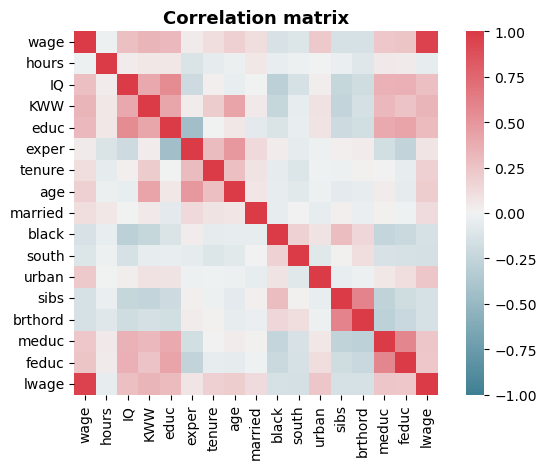

In [9]:
fig,ax=plt.subplots()
variables=['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','married','black','south','urban','sibs','brthord','meduc','feduc','lwage']
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(train[variables].corr(), vmax=1, vmin=-1, center=0, square=True, ax=ax, cmap=cmap)
ax.set_title('Correlation matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

The correlation heat-map illustrates some strong positive and negative correlations between variables in this dataset. Positive correlations with the response variable wage exist for IQ, KWW, educ, feduc, urban. Years of experience, however, barely correlated with the variable wage. 



In [10]:
train[variables].corr().round(2)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
wage,1.00,-0.02,0.27,0.33,0.31,0.04,0.12,0.18,0.11,-0.14,-0.11,0.22,-0.15,-0.14,0.23,0.25,0.96
hours,-0.02,1.00,0.04,0.06,0.06,-0.12,-0.06,-0.03,0.06,-0.04,-0.02,-0.00,-0.03,-0.10,0.05,0.04,-0.05
IQ,0.27,0.04,1.00,0.40,0.55,-0.20,0.02,-0.04,-0.01,-0.29,-0.14,0.03,-0.24,-0.18,0.35,0.36,0.28
KWW,0.33,0.06,0.40,1.00,0.42,0.03,0.20,0.42,0.05,-0.24,-0.05,0.09,-0.25,-0.16,0.31,0.26,0.33
educ,0.31,0.06,0.55,0.42,1.00,-0.44,-0.00,0.05,-0.07,-0.12,-0.04,0.08,-0.20,-0.18,0.39,0.42,0.30
exper,0.04,-0.12,-0.20,0.03,-0.44,1.00,0.29,0.49,0.13,0.03,-0.06,-0.02,0.02,0.04,-0.18,-0.26,0.07
tenure,0.12,-0.06,0.02,0.20,-0.00,0.29,1.00,0.27,0.08,-0.06,-0.11,-0.01,-0.02,0.02,0.00,-0.05,0.18
age,0.18,-0.03,-0.04,0.42,0.05,0.49,0.27,1.00,0.07,-0.05,-0.08,-0.02,-0.07,-0.05,0.04,-0.06,0.20
married,0.11,0.06,-0.01,0.05,-0.07,0.13,0.08,0.07,1.00,-0.05,0.00,-0.05,0.02,-0.04,0.01,-0.01,0.12
black,-0.14,-0.04,-0.29,-0.24,-0.12,0.03,-0.06,-0.05,-0.05,1.00,0.18,0.08,0.28,0.15,-0.24,-0.21,-0.15


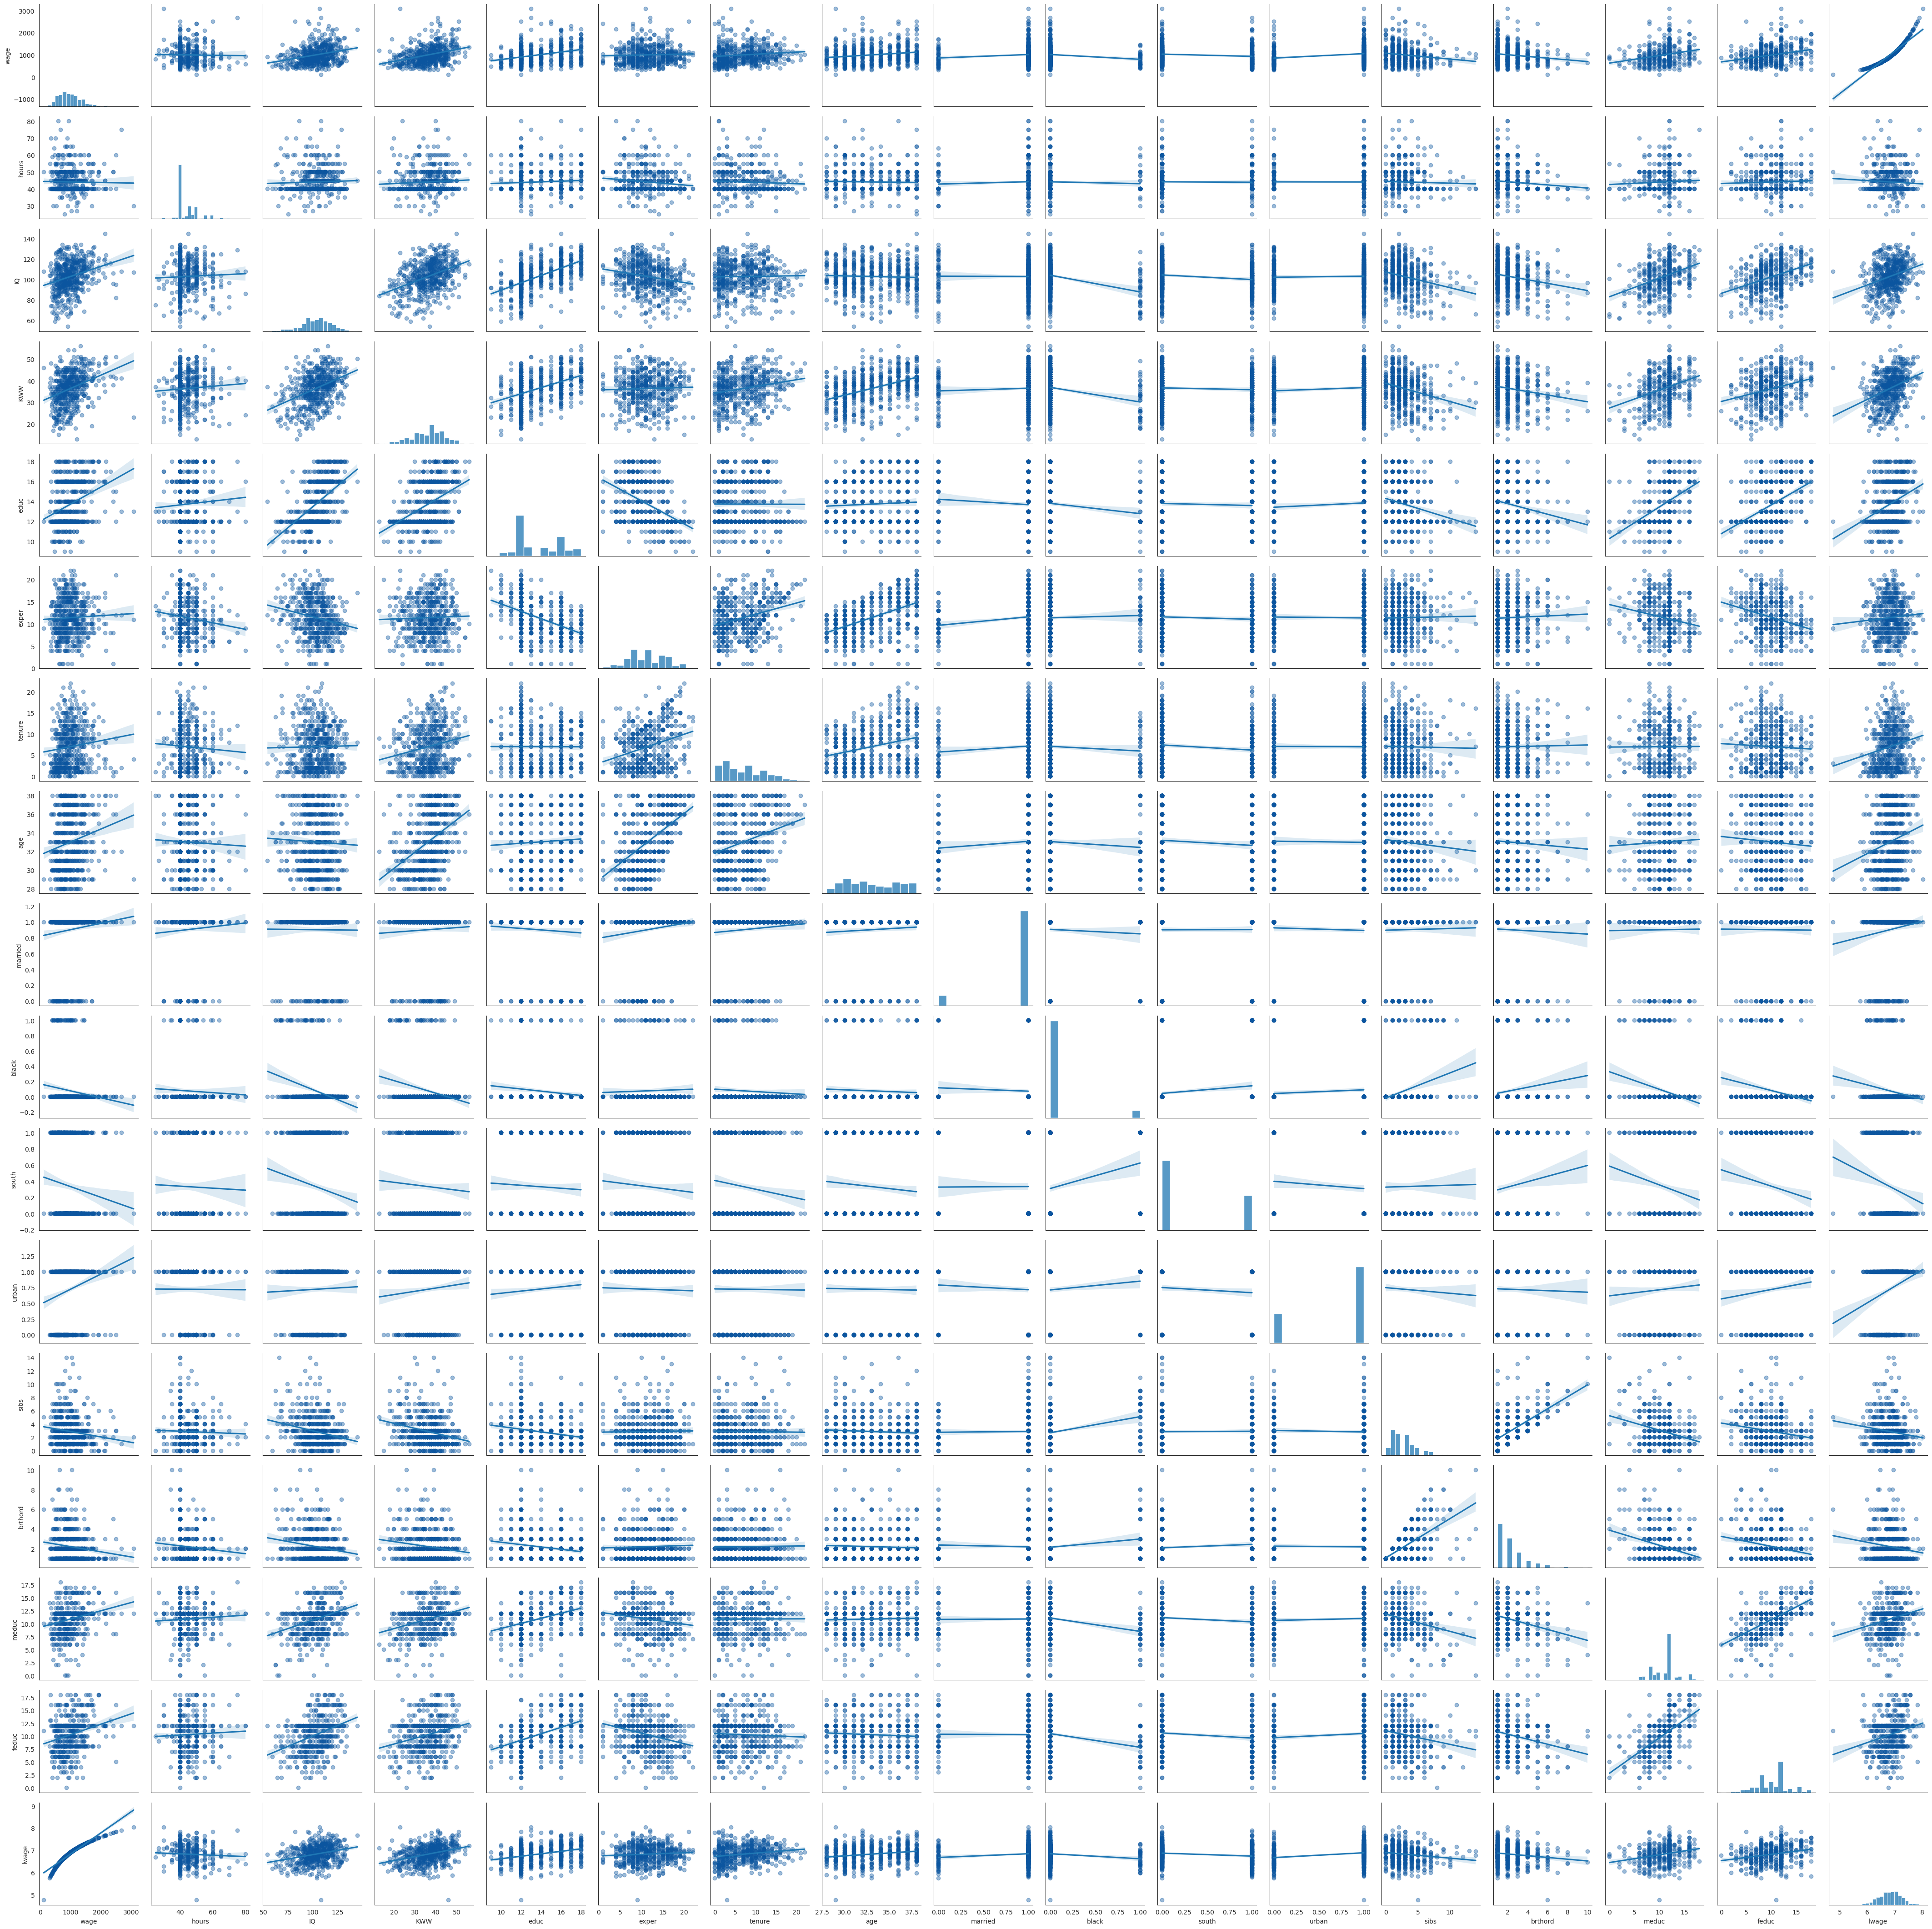

In [11]:
with sns.axes_style('white'):
    g=sns.pairplot(train[variables], kind='reg',
                   plot_kws={'scatter_kws' :{'color': sns.color_palette('Blues')[-1], 'alpha': 0.4}})
plt.tight_layout()
g.fig.savefig('DM-pairplot.png', dpi=300)
plt.show()

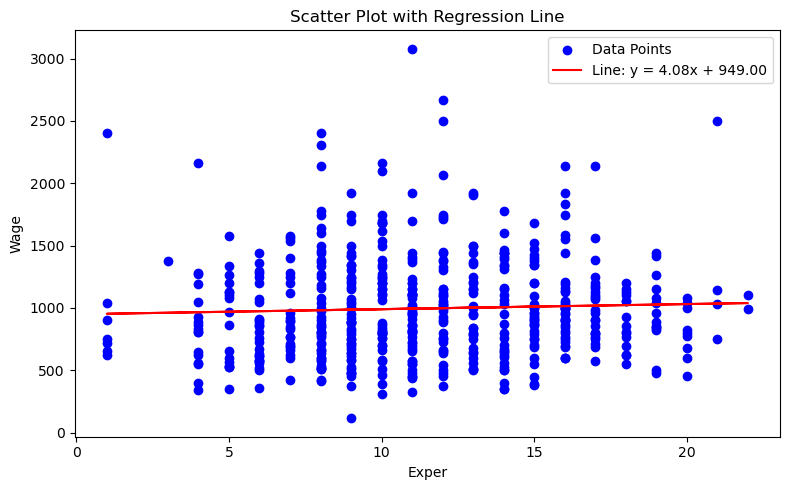

In [12]:
m, c = np.polyfit(train['exper'], train['wage'], 1)  # 1 means linear

# Generate y values for the regression line
wage_pred = m * train['exper'] + c

# Plot scatter and regression line
plt.figure(figsize=(8, 5))
plt.scatter(train['exper'], train['wage'], color='blue', label='Data Points')
plt.plot(train['exper'], wage_pred, color='red', label=f'Line: y = {m:.2f}x + {c:.2f}')
plt.title('Scatter Plot with Regression Line')
plt.xlabel('Exper')
plt.ylabel('Wage')
plt.legend()
plt.tight_layout()
plt.show()


Clear positive relationships exist between wage and variables such as IQ, KWW, and education. These relationships appear approximately linear and relatively strong, suggesting these variables may be important predictors in modeling wage. For example, as education increases, average wages also tend to rise, which aligns with economic expectations.

However, some relationships are more complex. The relationship between wage and experience (exper) flattern after a certain point, suggesting a potential non-linear trend. This plateau effect implies that while early years of experience may boost wages, the marginal gains diminish with time. A similar pattern is observed with tenure, when the upward trend is present but less clearly defined, indicating the need for potential modeling with squared or interaction terms to better capture the relationship. 

Several categorical variables such as married, black, south, and urban show distinct groupings in wage. For example, married individuals tend to have slightly higher wages, while the black and south categories show a mild negative association. These groupings suggest tht such variables might influence wages through interaction effects or differences in variance rather than through mean differences alone. 

Background variables like sibs and birthord show weak negative relationships with wage. This could indicate that individuals from larger families or with later birth order positions might receive fewer resources or opportunities during development, but these effects appear small and unlikely to serve as strong predictors in isolation. 

Regarding the parental education variables (meduc and feduc), the relationships with wage are present but weak. This suggests background factors may have some influence, potentially due to better access to educational resources or inherited values regarding education and ambition, though they are not as predictive as an individual's own education or ability (as proxied by IQ and KWW).

In terms of relationships between the predictors, no extremely strong correlations are observed that would suggest problematic multicollinearity. While there are some moderate associations (e.g., between educ and IQ, or tenure and age), none are strong enough to cause immediate concern for variance inflation in the regression model. At this stage, multicollinearity does not appear to be a major issue.

In [13]:
train[['wage','educ','exper']].describe().round(2)

,wage,educ,exper
count,531.00,531.00,531.00
mean,995.62,13.73,11.41
std,409.45,2.25,4.26
min,115.00,9.00,1.00
25%,700.00,12.00,8.00
50%,929.00,13.00,11.00
75%,1201.50,16.00,15.00
max,3078.00,18.00,22.00


In [14]:
model = smf.ols(formula='wage ~ hours +  IQ + KWW + educ + exper + tenure + age + married + black + south + urban + sibs + brthord + meduc + feduc', data=train)
reg = model.fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     10.70
Date:                Wed, 28 May 2025   Prob (F-statistic):           1.22e-22
Time:                        12:07:54   Log-Likelihood:                -3874.8
No. Observations:                 531   AIC:                             7782.
Df Residuals:                     515   BIC:                             7850.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -594.3412    260.485     -2.282      0.023   -1106.085     -82.597
hours         -2.2238      2.215     -1.004      0.316      -6.576       2.128
IQ             1.9545      1.405      1.391      0.165      -0.807       4.716
KWW            6.6200      2.785      2.377      0.018       1.149      12.091
educ          37.9593     10.413      3.646      0.000      17.503      58.416
exper         12.1049      5.264      2.300      0.022       1.763      22.447
tenure         2.5618      3.434      0.746      0.456      -4.185       9.308
age            5.9827      6.944      0.862      0.389      -7.659      19.625
married      146.8417     54.020      2.718      0.007      40.716     252.968
black        -67.0372     66.932     -1.002      0.317    -198.531      64.457
south        -27.3144     35.273     -0.774      0.439     -96.611      41.982
urban        170.7131     36.030      4.738      0.000      99.929     241.497
sibs           1.5727      9.227      0.170      0.865     -16.555      19.700
brthord      -11.2680     13.480     -0.836      0.404     -37.750      15.214
meduc          3.2926      7.307      0.451      0.652     -11.062      17.648
feduc         11.1663      6.228      1.793      0.074      -1.070      23.402
==============================================================================
Omnibus:                      164.611   Durbin-Watson:                   1.823
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              630.335
Skew:                           1.378   Prob(JB):                    1.33e-137
Kurtosis:                       7.571   Cond. No.                     2.08e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.08e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The effects of each variable can be summarized as:

Keeping all other variables constant, an increase of 1 average weekly hour is associated with an average decrease in the wage of 2.22 dollars.

Keeping all other variables constant, an increase of 1 IQ score is associated with an average increase in the wage of 1.95 dollars.

Keeping all other variables constant, an increase of 1 knowledge of world work score is associated with an average increase in the wage of 6.62 dollars.

Keeping all other variables constant, an increase of 1 year of education is associated with an average increase in the wage of 37.95 dollars.

Keeping all other variables constant, an increase of 1 year of experience is associated with an average increase in the wage of 12.1 dollars.

Keeping all other variables constant, an increase of 1 year with current employer is associated with an average decrease in the wage of 2.56 dollars.

Keeping all other variables constant, an increase of 1 age is associated with an average increase in the wage of 5.98 dollars.

Keeping all other variables constant, married people earns 146.84 dollars on average more than others. 

Keeping all other variables constant, black people earns 67.03 dollars on average less than others. 

Keeping all other variables constant, south people earns 27.31 dollars on average less than others. 

Keeping all other variables constant, urban people earns 170.71 dollars on average more than others. 

Keeping all other variables constant, an increase of 1 sibling is associated with an average increase in the wage of 1.57 dollars.

Keeping all other variables constant, an increase of 1 birth order is associated with an average decrease in the wage of 11.27 dollars.

Keeping all other variables constant, an increase of 1 year of mother's education is associated with an average increase in the wage of 3.29 dollars.

Keeping all other variables constant, an increase of 1 year of father's education is associated with an average increase in the wage of 11.17 dollars.


In [15]:
reg.mse_resid**0.5

362.69230272797444

In [16]:
model_base = smf.ols(formula='wage ~ educ + exper', data=train) 
regbase = model_base.fit()
regbase.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     41.43
Date:                Wed, 28 May 2025   Prob (F-statistic):           1.93e-17
Time:                        12:07:54   Log-Likelihood:                -3908.1
No. Observations:                 531   AIC:                             7822.
Df Residuals:                     528   BIC:                             7835.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -264.3942    142.291     -1.858      0.064    -543.921      15.133
educ          74.1534      8.201      9.042      0.000      58.043      90.263
exper         21.2275      4.323      4.910      0.000      12.735      29.720
==============================================================================
Omnibus:                      135.138   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              389.743
Skew:                           1.220   Prob(JB):                     2.34e-85
Kurtosis:                       6.416   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

As in the full model, the variable educ is positively related to wage, after accounting for the effect of exper. Again, exper is positively related to wage, after accounting for the effect of educ. The effects of each variable can be summarized as:

Keeping years of work excperience constant, an increase of 1 year of education is associated with an average increase in the wage of 74.15 dollars.
Keeping years of education constant, an increase of 1 year of experience is associated with an average increase in the wage of 21.23 dollars.

It is also noticeable that these estimates, though of the same sign, are quite different to their respective etimates in the full model. This could be evidence of some omitted variable bias (OVB) in this reduced model, for both variables. We consider this in more detail in part (i).


In [17]:
residbase=regbase.resid
fitbase=regbase.fittedvalues
regbase.mse_resid**0.5

381.38333895467895

In [18]:
1/(1-0.460066**2)

1.2684893812795168

The full model has $R^2 = 0.238$, $R^2_{adj} = 0.215$ and SER = $362.69$ dollars.
The reduced model has $R^2 = 0.136$, $R^2_{adj} = 0.132$ and SER = $381.38$ dollars.

The full model captures about $22\%$ of the variation in wages, with a typical prediction error of about $\$362$. The reduced model captures about $13\%$ of the variation in wages, with a typical prediction error of about $\$381$. Clearly, both models are pretty strong fits to the data, but the full model is the strongest fit between the two, capturing about $9$ percentage point more variation in wages and reducing the prediction error by about $\$19$.   

The variance inflation can be measured by the $R^2$ in the regression of one regressor on the other. Both equal to $\frac{1}{1-r^2}$, where $r$ is the correlation between educ and exper, as calculated above, equal 1.27. This is not a large number -- the usual threshold for the presence of a multicollinearity problem is 5.


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


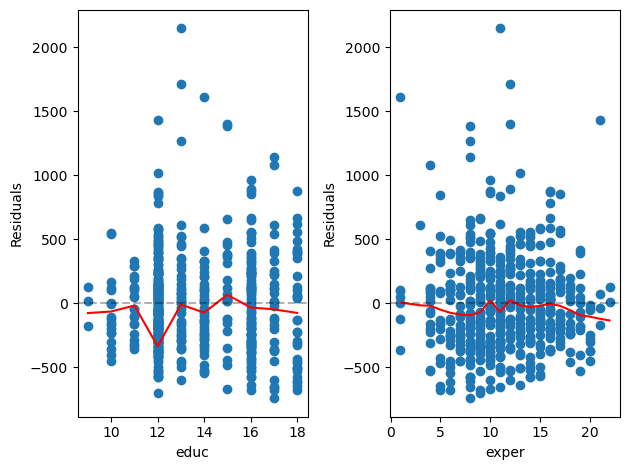

In [19]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

lowess = sm.nonparametric.lowess

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~regbase.resid.isna() & 
    ~train['educ'].isna() & 
    np.isfinite(regbase.resid) & 
    np.isfinite(train['educ'])
)
ax1.scatter(train['educ'], regbase.resid)
z1 = lowess(regbase.resid[mask1], train['educ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('educ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~regbase.resid.isna() & 
    ~train['exper'].isna() & 
    np.isfinite(regbase.resid) & 
    np.isfinite(train['exper'])
)
ax2.scatter(train['exper'], regbase.resid)
z2 = lowess(regbase.resid[mask2], train['exper'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('exper')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

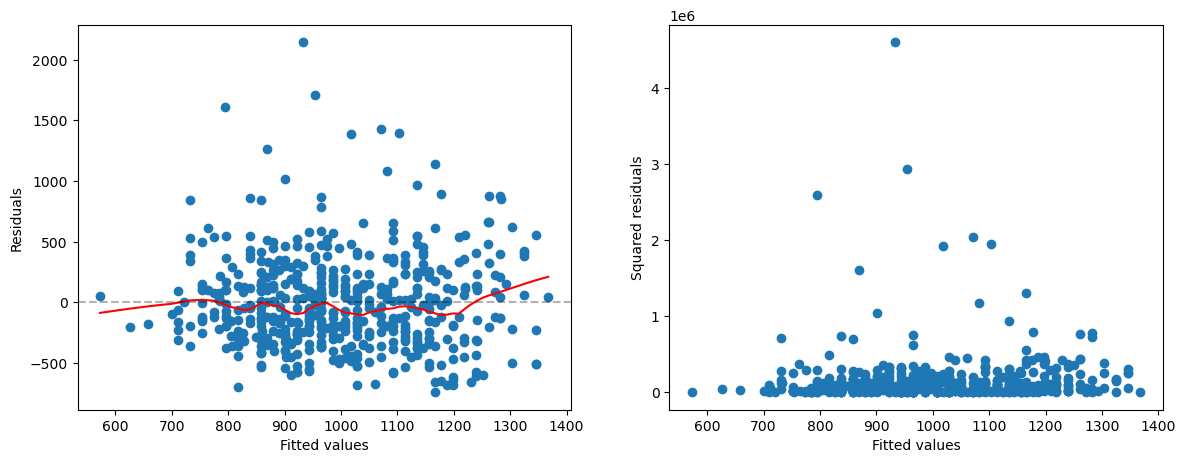

In [20]:
#Residual and squared residual plots against fitted values
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(regbase.fittedvalues,regbase.resid)
z1=lowess(regbase.resid,regbase.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
residbase2=regbase.resid**2
ax2.scatter(regbase.fittedvalues,residbase2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

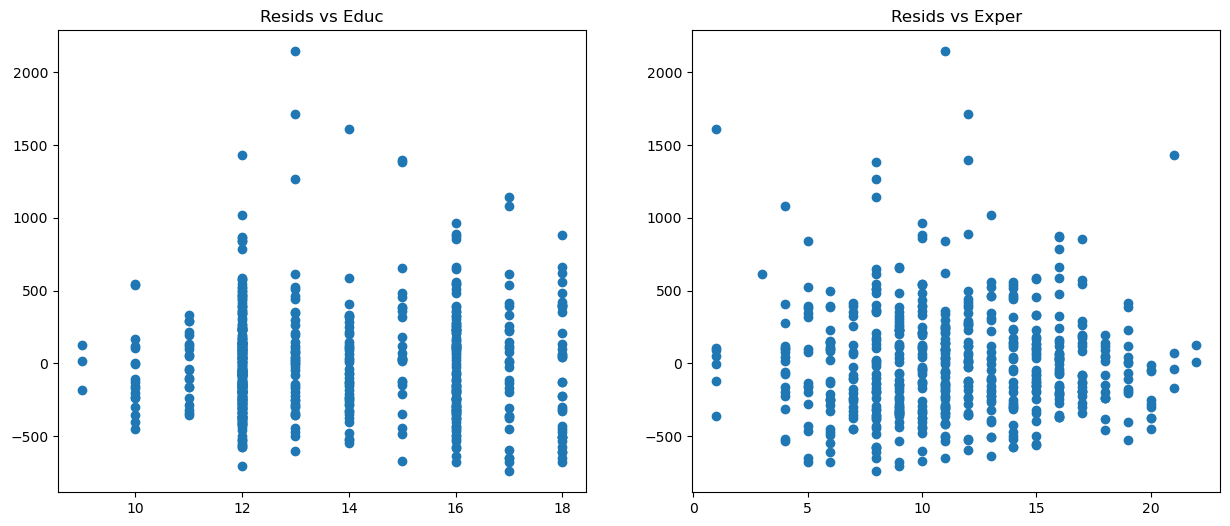

In [21]:
fig = plt.figure(figsize=(15,6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
ax1.scatter(train['educ'],residbase)
ax1.set_title("Resids vs Educ")
ax2.scatter(train['exper'], residbase)
ax2.set_title("Resids vs Exper")
plt.show()

The residuals vs fitted values plot shows no clear pattern in the mean, i.e. the errors seem to average close to 0 for most fitted values, as confirmed by the LOESS curve (apart from a mild dip in the middle). The residuals vs each predictor show that **E**$(e|X) = 0$ appears to hold for most value of $X$. Thus, the linear model seems a reasonable fit for the wage data.

However, there is evidence that the variance of residuals increases slightly for higher fitted values. This is visible in the squared residuals plot, where spread is larger at the extremes. Hence, the assumption of constant variance may not hold, and inference may benefit from using heteroskedasticity-robust standard errors.

The scatter plots of wage against each predictor (in blue), overlaid with fitted values (in orange), offer additional insights:

For **education**, the orange predicted values track the increasing trend in wage with rising education, though they tend to underpredict for higher earners.

For **experience**, a similar pattern is observed: predictions follow the general shape of the data but fail to capture some curvature or variance at higher experience levels. These plots suggest that the model captures the main linear trend well, though it might benefit from polynomial or interaction terms for more accuracy. 

Regarding the other MLR LSA:

**LSA 2** requires **E**$(e|X) = 0$. While the resiual plots support this assumption, it may still be violated due to **omitted variable bias**. For instance, IQ and KWW, which show a positive correlation with wage and likely correlate with educ, are not included in this model. This may bias the coefficient estimates for educ. 

**LSA 3** assumes that the observations are i.i.d. As we lack temporal or cluster structure in the data, we proceed under this assumption.

**LSA 4** concerns finite $4^{th}$ moments. As discussed above, the residual variance increases for larger fitted values, suggesting heteroskedasticity. This may affect the reliability of hypothesis tests and confidence intervals unless corrected. 

**LSA 5** (no perfect multicollinearity): educ and exper and only moderately correlated (~0.44), which is well below the threshold for concern. Hence, no multicollinearity issues are detected. 

In [22]:
#calculate VIFs for predictors
features=train[['educ','exper']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 1.238
VIF for exper: 1.238
Average VIF: 1.238


The variable IQ is likely a source of OVB as it is positively correlated with both education ($r=0.55$) and wage ($r=0.27$). Since IQ captures innate bility that affects both educational attainment and productivity, its omission may inflate the estimated return to education. Although not statistically significant ($p=0.165$), the strong correlation with $educ$ suggest potential bias.

Similarly, KWW is positively associated with $educ (r=0.42$) and $wage (r=0.33$), and is statistically significant in the full model ($p=0.018$). As a proxy for job knowledge, KWW likely mediates the education-wage link, and its exclusion may also bias the $educ$ coefficient upward.

The variable $feduc$ is a likely source of omitted variable bias as it is positively correlated with both education ($r = 0.42$) and wage ($r = 0.25$). As a measure of parental socioeconomic background, father’s education can influence both a child's access to education and their future earning potential through early-life advantages such as support, expectations, and educational resources. Although the coefficient on $feduc$ is not always statistically significant in the full model ($p = 0.074$), its strong correlation with $educ$ suggests that omitting it may bias the estimated return to education upward.

Similarly, $medu$c is positively correlated with both education ($r = 0.39$) and wage ($r = 0.23$). As with feduc, mother’s education likely shapes a child’s learning environment and ambition, which in turn affect their educational attainment and labour market outcomes. While $medu$c tends to have a weaker statistical impact than $feduc$, its exclusion could still contribute to upward bias in the educ coefficient by failing to account for background-driven differences in schooling.

Among the variables identified as potential sources of omitted variable bias — $IQ, KWW, feduc$, and $meduc$ — we include only IQ and feduc in our multiple linear regression model.

All four variables are positively correlated with both education and wage, suggesting they may confound the estimated return to education if excluded. However, we limit our selection to $IQ$ and $feduc$ to avoid redundancy and multicollinearity, while still capturing the most explanatory information.

IQ and KWW are moderately correlated ($r = 0.40$), and both capture aspects of cognitive ability and job knowledge. Since IQ is more strongly correlated with education ($r = 0.55$) and theoretically represents innate ability - a more foundational determinant of both education and wage - we prioritize it over $KWW$.

Similarly, feduc and meduc are highly correlated ($r = 0.58$), as expected from parental education measures. Including both would likely introduce multicollinearity without significant additional explanatory power. We choose $feduc$ over $meduc$ based on its stronger correlation with wage ($r = 0.25$) and its better performance in model selection metrics such as adjusted $R^2$. Thus, by including $IQ$ and $feduc$, we account for key omitted factors related to ability and socioeconomic backgorund while maintaining model parsimony and stability.

As side notes, $urban$ and $married$ are statistically significant ($p < 0.001$), but weakly correlated with $educ$ and $exper (r<0.09$), suggesting their omission is less likely to bias key coefficients, though they may improve model fit. Other controls have weaker links and are less concerning for OVB. 

In [23]:
newmodel = smf.ols(formula='wage ~ educ + exper + IQ + feduc', data=train)
newreg = newmodel.fit()
newreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     26.20
Date:                Wed, 28 May 2025   Prob (F-statistic):           7.90e-20
Time:                        12:07:55   Log-Likelihood:                -3898.6
No. Observations:                 531   AIC:                             7807.
Df Residuals:                     526   BIC:                             7829.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -476.7948    154.895     -3.078      0.002    -781.084    -172.506
educ          52.6849      9.716      5.422      0.000      33.597      71.772
exper         22.1240      4.285      5.164      0.000      13.707      30.541
IQ             2.9745      1.341      2.218      0.027       0.340       5.609
feduc         18.5483      5.559      3.337      0.001       7.627      29.469
==============================================================================
Omnibus:                      135.687   Durbin-Watson:                   1.823
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              411.531
Skew:                           1.205   Prob(JB):                     4.34e-90
Kurtosis:                       6.577   Cond. No.                     1.01e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.01e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In the expanded model, both $educ$ and $exper$ reamin statistically significant. The estimated coefficient for education is $52.68$ with a $p-value = 0$, and for experience, it is $22.12$ with a $p-value = 0$. These results confirm that, even after controlling for additional variables, education and experience are each positively associated with wage, and the relationships are statistically meaningful at the $5%$ level.

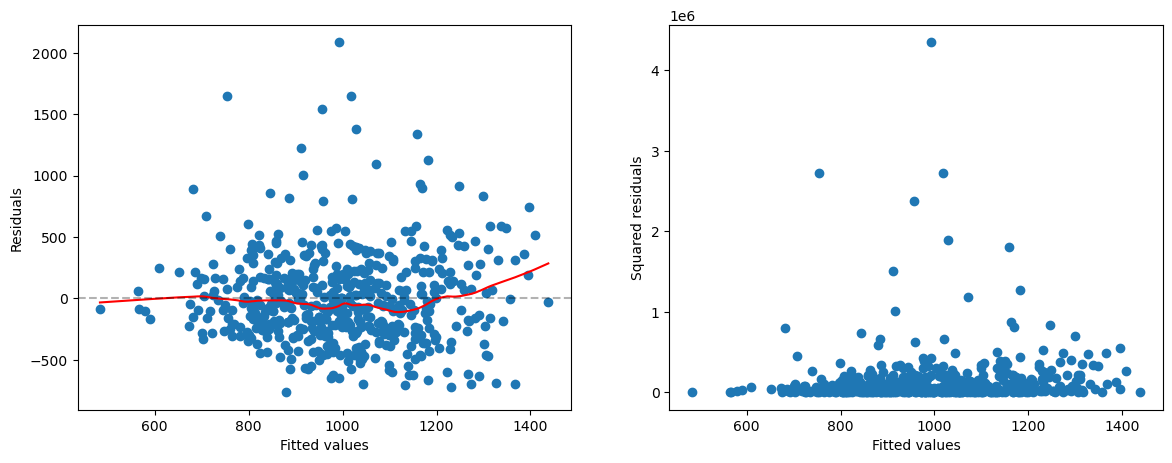

In [24]:
lowess = sm.nonparametric.lowess
#Residual and squared residual plots against fitted values
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(newreg.fittedvalues,newreg.resid)
z1=lowess(newreg.resid,newreg.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
newreg2=newreg.resid**2
ax2.scatter(newreg.fittedvalues,newreg2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

In [25]:
newresid=newreg.resid
newfit=newreg.fittedvalues
newreg.mse_resid**0.5

375.3091875260345

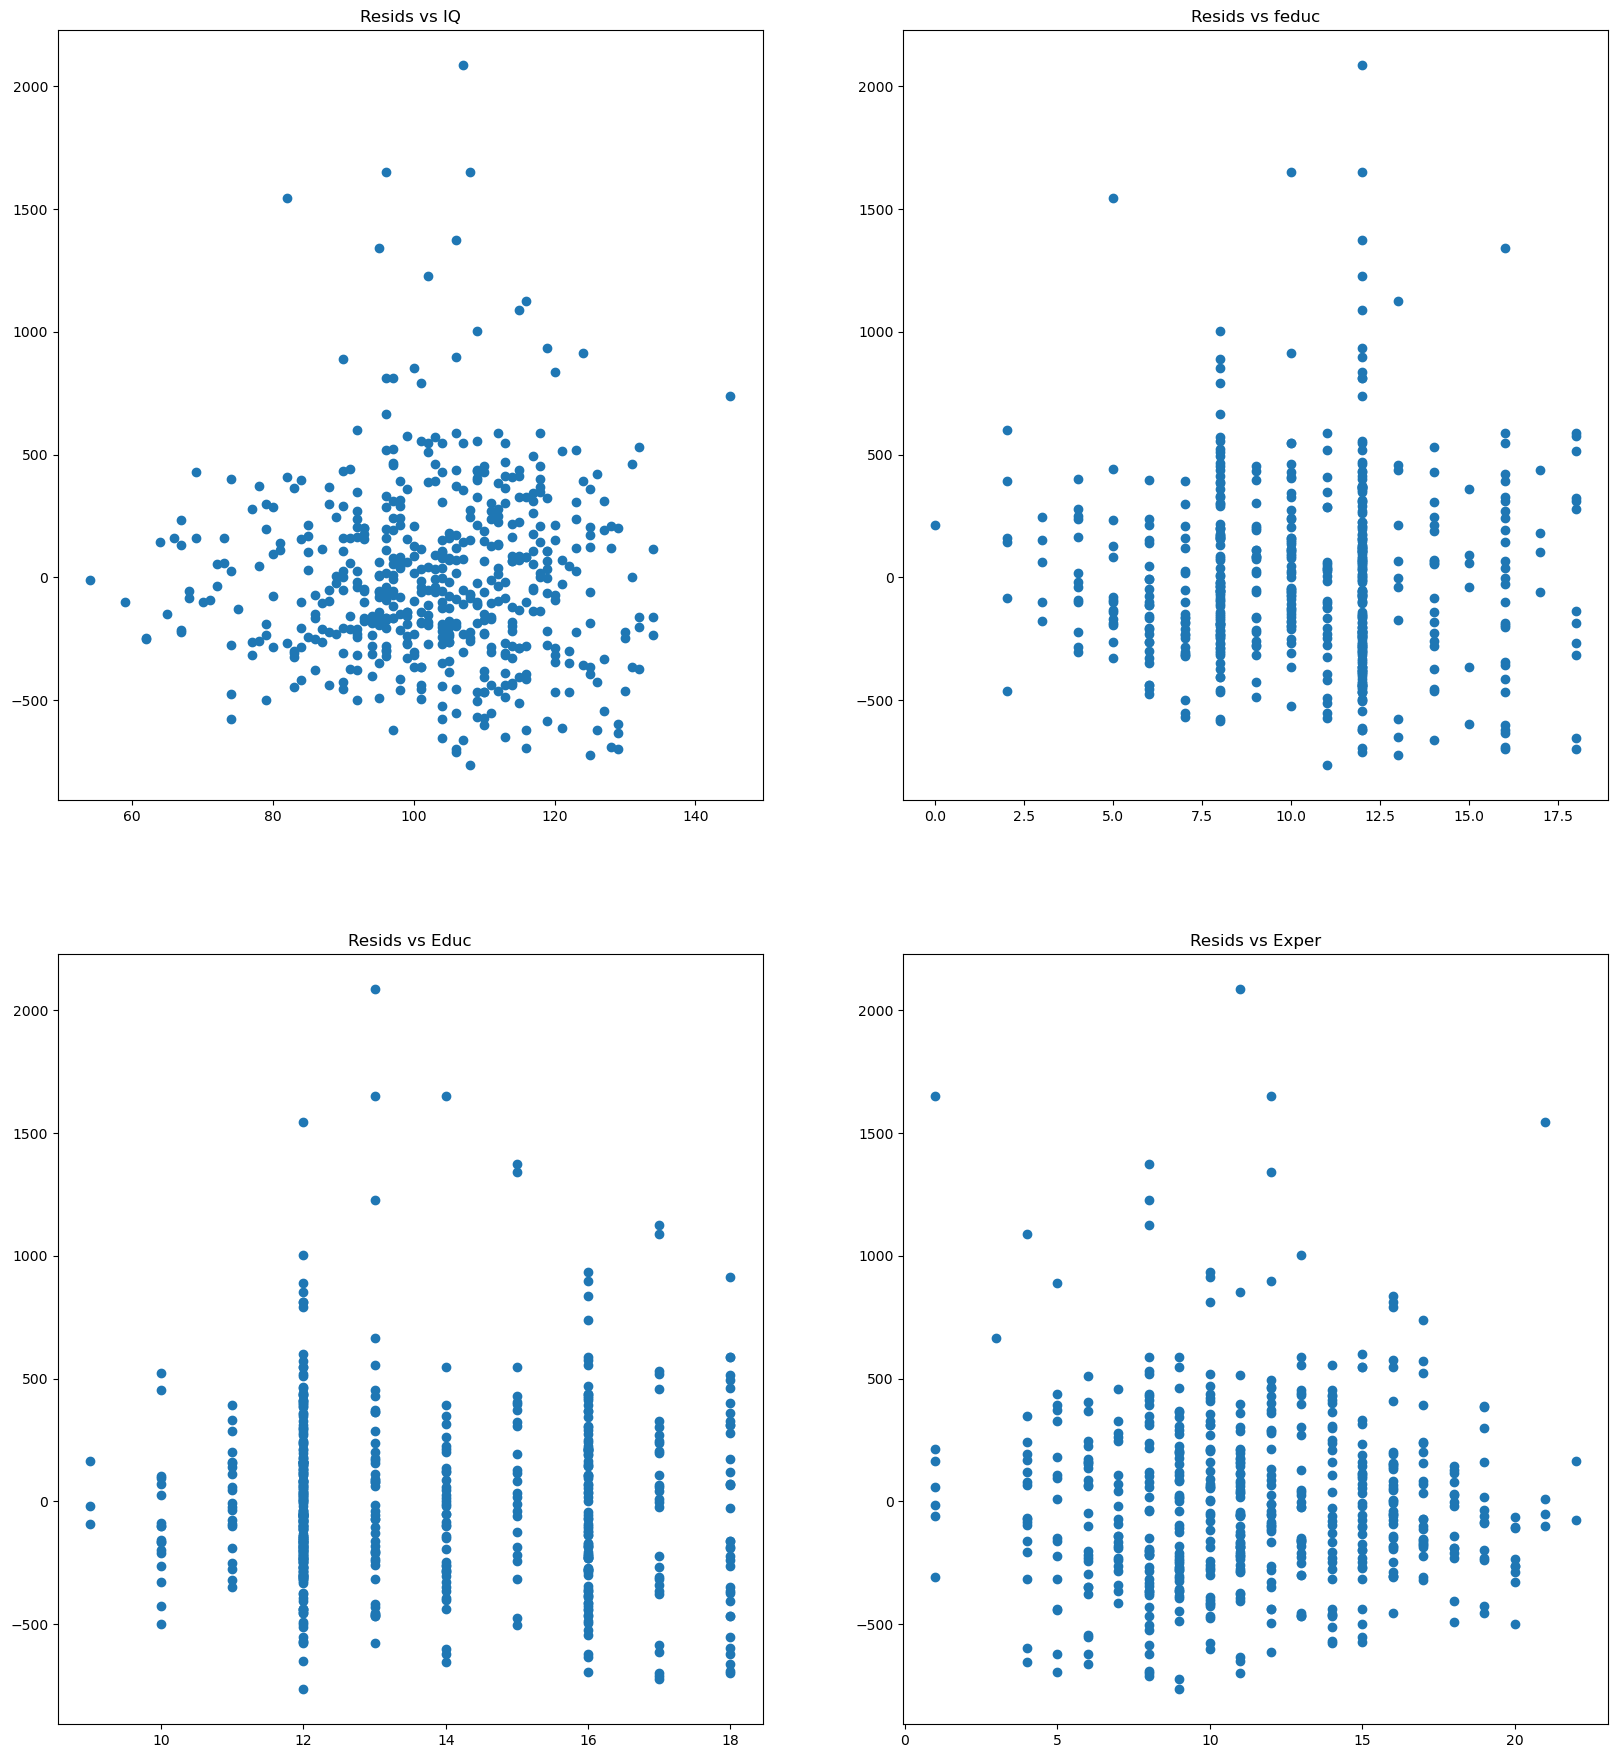

In [26]:
fig,ax=plt.subplots(2,2,figsize=(20,22))
ax[0,0].scatter(train['IQ'],newresid)
ax[0,0].set_title("Resids vs IQ")
ax[0,1].scatter(train['feduc'], newresid)
ax[0,1].set_title("Resids vs feduc")
ax[1,0].scatter(train['educ'],newresid)
ax[1,0].set_title("Resids vs Educ")
ax[1,1].scatter(train['exper'], newresid)
ax[1,1].set_title("Resids vs Exper")
plt.show()

In [27]:
#calculate VIFs for predictors
features=train[['educ','exper','IQ', 'feduc']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 1.795
VIF for exper: 1.256
VIF for IQ: 1.476
VIF for feduc: 1.268
Average VIF: 1.449


The original reduced MLR was esimated as: $\hat{Wage} = -264.39 + 74.15 \times \mbox{educ} + 21.23 \times \mbox{exper}$. 95% confidence intervals for the two slopes are: $(58.04, 90.26)$ and $(12.74,29.72)$.

The new MLR is estimated as: $\hat{Wage} = -476.79 + 52.68 \times \mbox{educ} + 22.12 \times \mbox{exper} + 2.97 \times \mbox{IQ} + 18.54 \times \mbox{feduc}$. $95%$ confidence intervals for the four slopes are: $(33.6,71.77), (13.71,30.54), (0.34,5.61)$,and $(7.63,29.47)$.

The estimated effect of educ in five-variable MLR has dropped to be lower than the 95% CI from the two-variable MLR. Clearly, IQ and feduc were was causing some OVB in this estimated effect in the two variable MLR.

The estimated effect of exper has become more positive, however the two 95% CIs have a large overlap and the difference in estimate here can probably be put down to simply estimation error, rather than OVB. 

For the added variables:

All variables are statistically significant, consistent with expectations.


The variance inflation can be measured by the $R^2$ in the regression of one regressor on the other. Both equal to $\frac{1}{1-r^2}$, where $r$ is the correlation between two variables, as calculated above, equal around 1. This is not a large number -- the usual threshold for the presence of a multicollinearity problem is 5.

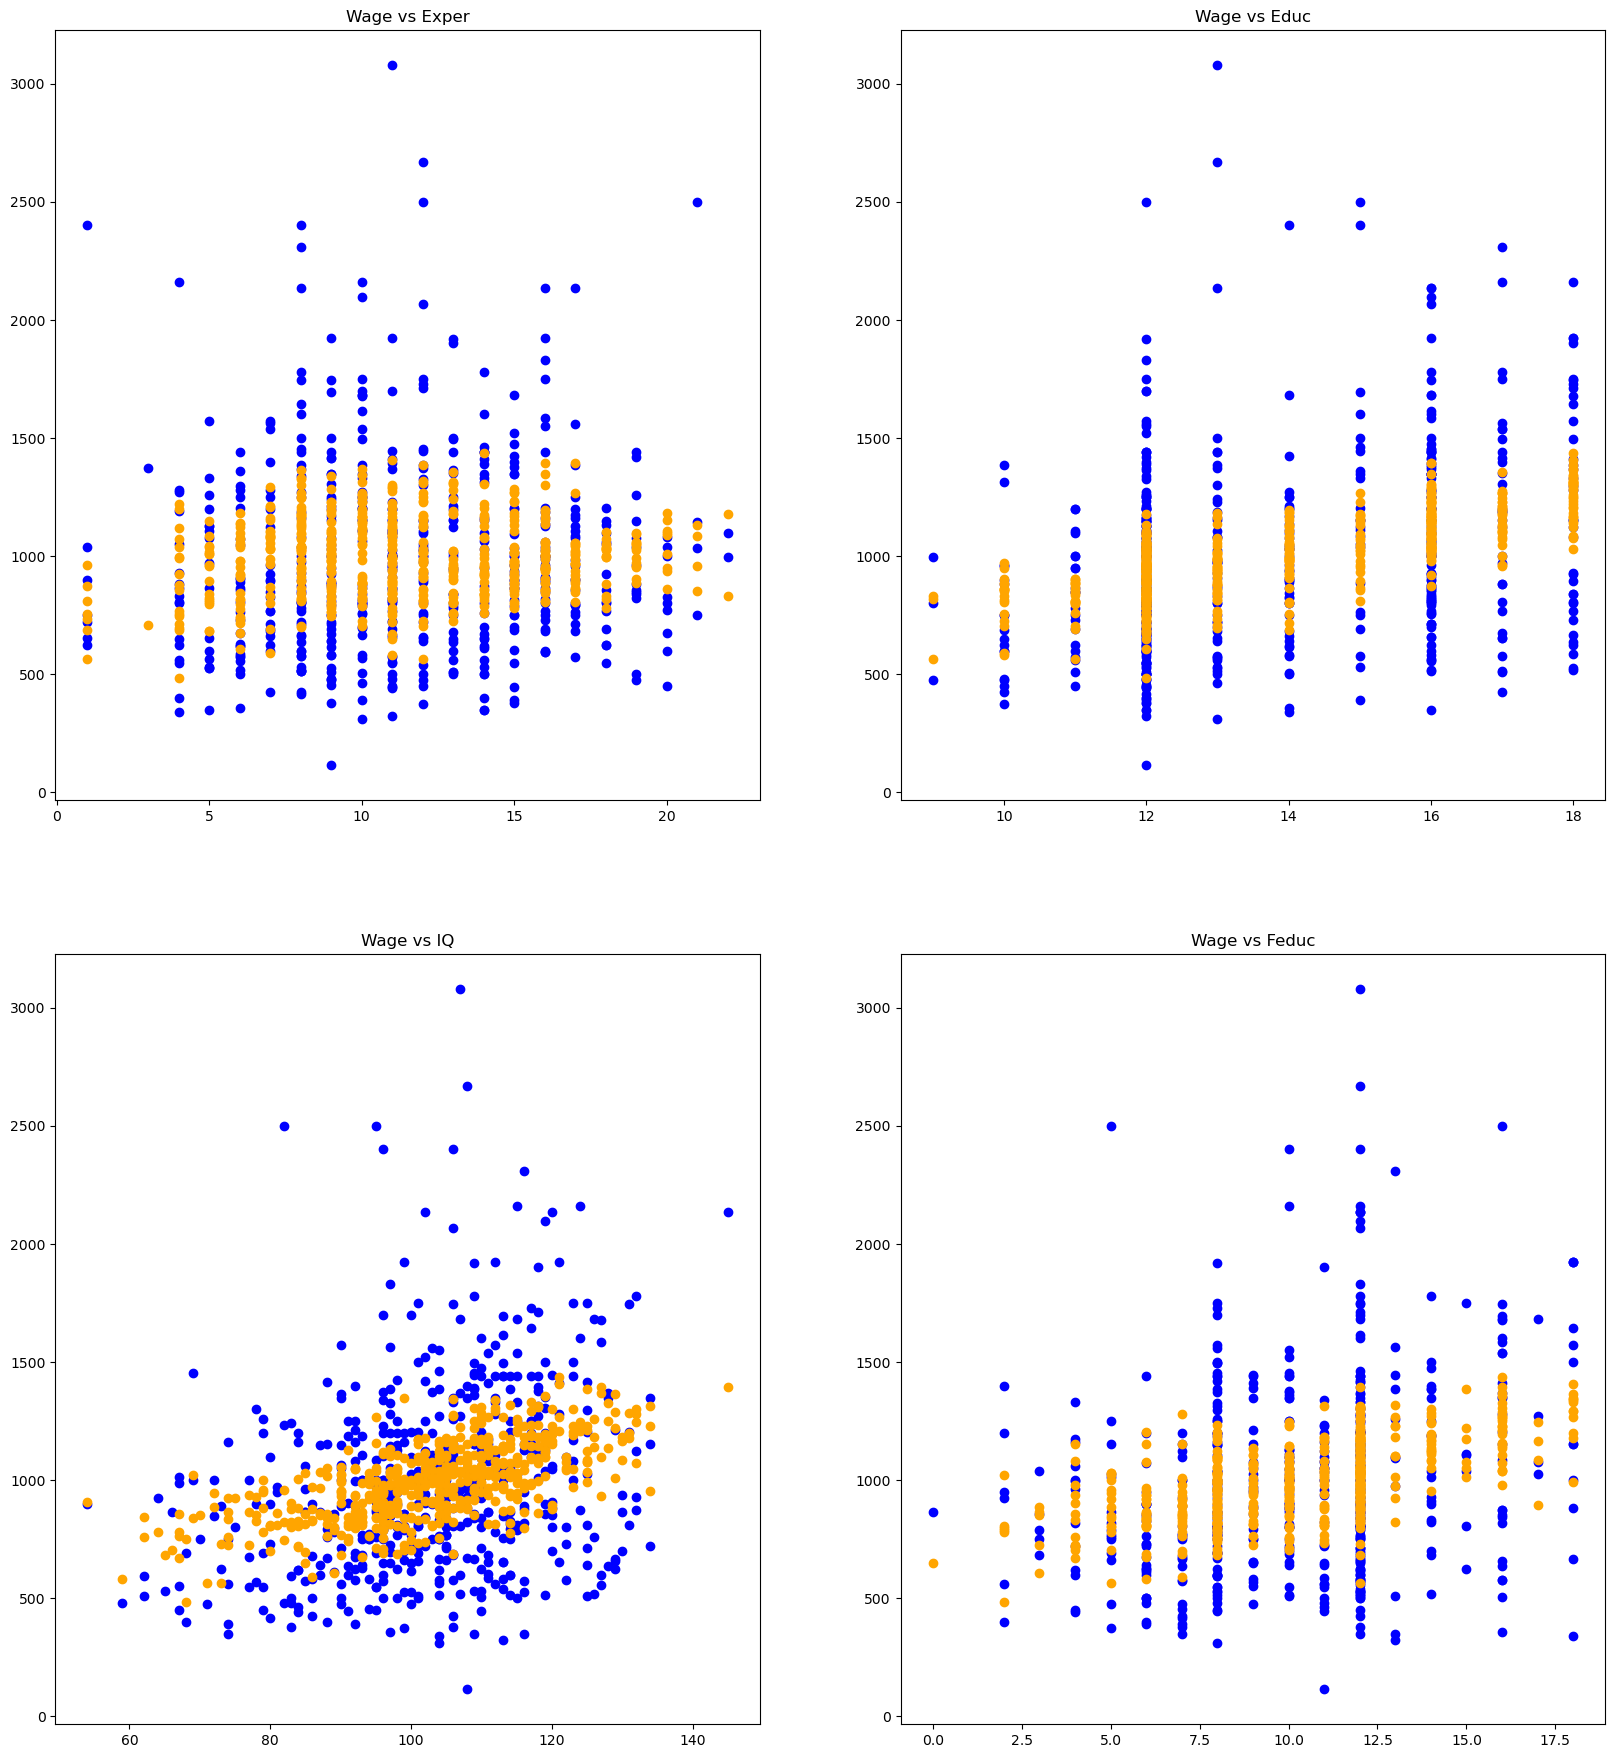

In [28]:
fig,ax=plt.subplots(2,2,figsize=(20,22))
ax[0,0].scatter(train['exper'], train['wage'], c='blue')
ax[0,0].scatter(train['exper'], newfit, c='orange')

ax[0,0].set_title('Wage vs Exper')
ax[0,1].scatter(train['educ'], train['wage'], c='blue')
ax[0,1].scatter(train['educ'], newfit, c='orange')

ax[0,1].set_title('Wage vs Educ')
ax[1,0].scatter(train['IQ'], train['wage'], c='blue')
ax[1,0].scatter(train['IQ'], newfit, c='orange')

ax[1,0].set_title('Wage vs IQ')
ax[1,1].scatter(train['feduc'], train['wage'], c='blue')
ax[1,1].scatter(train['feduc'], newfit, c='orange')

ax[1,1].set_title('Wage vs Feduc')

plt.show()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


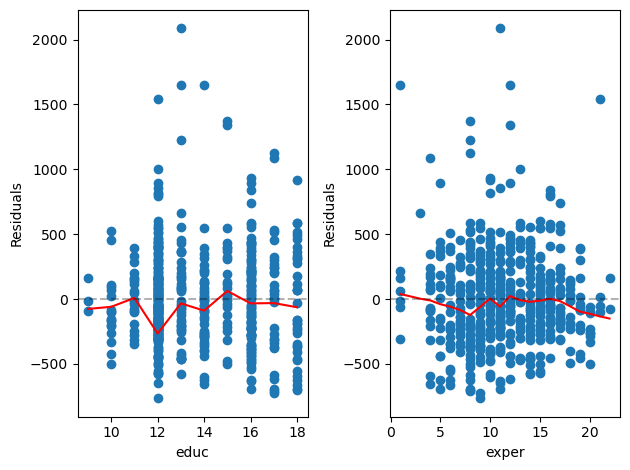

In [29]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

lowess = sm.nonparametric.lowess

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~newreg.resid.isna() & 
    ~train['educ'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['educ'])
)
ax1.scatter(train['educ'], newreg.resid)
z1 = lowess(newreg.resid[mask1], train['educ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('educ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~newreg.resid.isna() & 
    ~train['exper'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['exper'])
)
ax2.scatter(train['exper'], newreg.resid)
z2 = lowess(newreg.resid[mask2], train['exper'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('exper')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

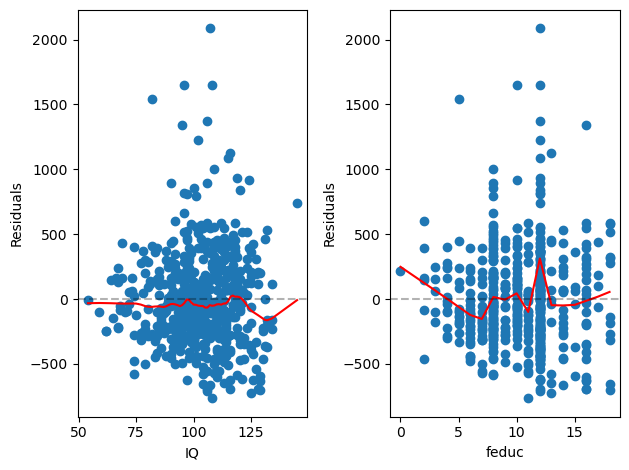

In [30]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

lowess = sm.nonparametric.lowess

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~newreg.resid.isna() & 
    ~train['IQ'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['IQ'])
)
ax1.scatter(train['IQ'], newreg.resid)
z1 = lowess(newreg.resid[mask1], train['IQ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('IQ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~newreg.resid.isna() & 
    ~train['feduc'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['feduc'])
)
ax2.scatter(train['feduc'], newreg.resid)
z2 = lowess(newreg.resid[mask2], train['feduc'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('feduc')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

The residuals vs fitted values plot shows that residuals are generally centered around zero, supporting the asusmption that $E(\epsilon|X) = 0$. The LOESS curve remains mostly flat, with no strong curvature, indicating that the linear functional form is reasonable approximation. However, residual spread appears to increase at higher fitted values, suggesting potential heteroskedasticity. The sqaured residual plot supports this, with some outliers at the upper end. Therefore, standard errors may benefit from heteroskedasticity-robust correction. 

The scatter plots of wage against each predictor, overlaid with fitted values (in orange), show that the linear model captures the main trends effectively. For education, predictions track the positive relationship with wage, though underprediction may occur for higher education levels. For experience, a similar trend is observed, but the wage gain appears to plateau. Including $exper^2$ in a later model may better capture this curvature. For IQ, the relationship is linear and strong, while $feduc$ shows a weaker but positive association.

Regarding the other MLR assumptions:

LSA 2 (Zero conditional mean): The residual plots support this assumption. Furthermore, including $IQ$ and $feduc$ helps reduce omitted variable bias from unobserved ability and family background that influence both education and wage. Their inclusion is supported by both theory and correlation structure.

LSA 3 (i.i.d. errors): The data is corss-sectional and lacks clustering or time structure, so this assumption is reasonably satisfied.

LSA 4 (Finite $4^{th}$ moments): Visual inspection of residual shows some outliers but no severe skewness or heavy tails. Predictors such as $IQ$ and $feduc$ are bounded and roughly symmetric. Thus, this assumption is likely to hold.

LSA 5 (No perfect multicollinearity): The correlation between $educ$ and $feduc$ is moderate ($0.42$), and between $IQ$ and $educ$ ($0.55$), which are acceptable. VIF values are not excessively high, so multicollinearity does not pose a major concern.

In conclusion, the reduced OVB model with $IQ$ and $feduc$ addresses key sources of bias and satisfies the main LSA conditions. While heteroskedasticity is present, it can be mitigated through robust standard errors. The model fits the data reasonably well and is appropriate for inference. 


In [31]:
#forward selection code
train['age2']=train['age']**2
import statsmodels.formula.api as smf

def forward_selected(data, response, nominated = []):
    """Linear model designed by forward selection.

    Parameters:
    -----------
    data : pandas DataFrame with all possible predictors and response

    response: string, name of response column in data

    Returns:
    --------
    model: an "optimal" fitted statsmodels linear model
           with an intercept
           selected by forward selection
           evaluated by adjusted R-squared
    """
    remaining = set(data.columns)
    selected = nominated
    remaining.remove(response)
    remaining ^= set(selected)
    current_score, best_new_score = 0.0, 0.0
    if nominated:
        formula = "{} ~ {} + 1".format(response, ' + '.join(nominated))
        current_score= smf.ols(formula, data).fit().rsquared_adj
        best_new_score = current_score
        print("you nominated variable(s) %s, the adj_r2 is: %f" %(nominated, current_score))
    while remaining and current_score == best_new_score:
        scores_with_candidates = []
        for candidate in remaining:
            formula = "{} ~ {} + 1".format(response,
                                           ' + '.join(selected + [candidate]))
            score = smf.ols(formula, data).fit().rsquared_adj
            scores_with_candidates.append((score, candidate))
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()
        if current_score < best_new_score:
            print("adding %s increases adj_r2 from %f to %f" %(best_candidate, current_score, best_new_score))
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
    formula = "{} ~ {} + 1".format(response,
                                   ' + '.join(selected))
    model = smf.ols(formula, data).fit()
    print("final model is %s, with adj_r2 of %f" %(formula, model.rsquared_adj))
    return model
#perform forward seledtion with 'wage' being the dependent variable
adj_wage_train=train.drop(columns=['lwage'])
model=forward_selected(adj_wage_train,response='wage',nominated=['educ','exper'])
model.summary()

you nominated variable(s) ['educ', 'exper'], the adj_r2 is: 0.132385
adding urban increases adj_r2 from 0.132385 to 0.167247
adding KWW increases adj_r2 from 0.167247 to 0.193701
adding feduc increases adj_r2 from 0.193701 to 0.205634
adding married increases adj_r2 from 0.205634 to 0.215716
adding IQ increases adj_r2 from 0.215716 to 0.218332
adding black increases adj_r2 from 0.218332 to 0.219238
adding south increases adj_r2 from 0.219238 to 0.219271
final model is wage ~ educ + exper + urban + KWW + feduc + married + IQ + black + south + 1, with adj_r2 of 0.219271


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     17.54
Date:                Wed, 28 May 2025   Prob (F-statistic):           1.83e-25
Time:                        12:07:56   Log-Likelihood:                -3876.6
No. Observations:                 531   AIC:                             7773.
Df Residuals:                     521   BIC:                             7816.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -591.2485    163.584     -3.614      0.000    -912.615    -269.882
educ          41.9721      9.953      4.217      0.000      22.418      61.526
exper         16.0167      4.332      3.697      0.000       7.505      24.528
urban        167.2836     35.770      4.677      0.000      97.013     237.554
KWW            7.8936      2.479      3.185      0.002       3.024      12.763
feduc         12.6656      5.483      2.310      0.021       1.893      23.438
married      146.8550     53.547      2.743      0.006      41.661     252.049
IQ             1.6995      1.358      1.251      0.211      -0.969       4.368
black        -71.9644     64.701     -1.112      0.267    -199.072      55.143
south        -34.8996     34.530     -1.011      0.313    -102.735      32.936
==============================================================================
Omnibus:                      156.179   Durbin-Watson:                   1.818
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              569.525
Skew:                           1.320   Prob(JB):                    2.13e-124
Kurtosis:                       7.333   Cond. No.                     1.18e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.18e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Both $feduc$ and $married$ are chosen during the forward selection process as they contribute meaningfully to explaining variation in wage. While $married$ is staistically significant and captures important life-stage or household structure effects, $feduc$ represents background socioeconomic advantages and may influence how individuals translate their own education into earnings. 

In [205]:
#perform forward selection with 'lwage' being the dependent variable
train['exper2'] = train['exper']**2
train['tenure2'] = train['tenure']**2
train['age2'] = train['age']**2
train['leduc']=np.log(train['educ'])
train['KWW_educ'] = train['KWW']*train['educ']
train['exper_educ'] = train['exper']*train['educ']
train['KWW_leduc'] = train['KWW']*train['leduc']
train['exper_leduc'] = train['exper']*train['leduc']
train['lhours']=np.log(train['hours'])
adj_lwage_train=train.drop(columns=['wage'])
modela=forward_selected(adj_lwage_train,response='lwage',nominated=['educ','exper','IQ','meduc'])
modela.summary()

you nominated variable(s) ['educ', 'exper', 'IQ', 'meduc'], the adj_r2 is: 0.166513
adding urban increases adj_r2 from 0.166513 to 0.208610
adding KWW_educ increases adj_r2 from 0.208610 to 0.224873
adding married increases adj_r2 from 0.224873 to 0.236539
adding tenure increases adj_r2 from 0.236539 to 0.243639
adding exper_educ increases adj_r2 from 0.243639 to 0.249615
adding south increases adj_r2 from 0.249615 to 0.253105
adding lhours increases adj_r2 from 0.253105 to 0.256792
adding KWW increases adj_r2 from 0.256792 to 0.259106
adding leduc increases adj_r2 from 0.259106 to 0.261538
adding exper_leduc increases adj_r2 from 0.261538 to 0.264580
adding black increases adj_r2 from 0.264580 to 0.267129
adding KWW_leduc increases adj_r2 from 0.267129 to 0.268801
adding tenure2 increases adj_r2 from 0.268801 to 0.269434
adding Step_age increases adj_r2 from 0.269434 to 0.269937
adding brthord increases adj_r2 from 0.269937 to 0.270421
final model is lwage ~ educ + exper + IQ + meduc 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     11.34
Date:                Wed, 28 May 2025   Prob (F-statistic):           9.26e-29
Time:                        13:20:52   Log-Likelihood:                -185.99
No. Observations:                 531   AIC:                             412.0
Df Residuals:                     511   BIC:                             497.5
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -23.3548     12.552     -1.861      0.063     -48.014       1.305
educ           -1.4898      0.565     -2.637      0.009      -2.600      -0.380
exper           0.9707      0.472      2.058      0.040       0.044       1.897
IQ              0.0020      0.001      1.497      0.135      -0.001       0.005
meduc           0.0105      0.006      1.660      0.097      -0.002       0.023
urban           0.1919      0.035      5.525      0.000       0.124       0.260
KWW_educ        0.0204      0.012      1.727      0.085      -0.003       0.044
married         0.1574      0.052      3.016      0.003       0.055       0.260
tenure          0.0220      0.010      2.124      0.034       0.002       0.042
exper_educ      0.0471      0.021      2.194      0.029       0.005       0.089
south          -0.0546      0.034     -1.611      0.108      -0.121       0.012
lhours         -0.2022      0.103     -1.968      0.050      -0.404      -0.000
KWW             0.3590      0.265      1.357      0.176      -0.161       0.879
leduc          19.3100      7.778      2.483      0.013       4.029      34.591
exper_leduc    -0.6147      0.293     -2.099      0.036      -1.190      -0.039
black          -0.1054      0.064     -1.655      0.098      -0.231       0.020
KWW_leduc      -0.2428      0.163     -1.486      0.138      -0.564       0.078
tenure2        -0.0008      0.001     -1.375      0.170      -0.002       0.000
Step_age        0.0081      0.007      1.169      0.243      -0.006       0.022
brthord        -0.0124      0.011     -1.157      0.248      -0.033       0.009
==============================================================================
Omnibus:                       34.665   Durbin-Watson:                   1.798
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              125.173
Skew:                          -0.106   Prob(JB):                     6.59e-28
Kurtosis:                       5.369   Cond. No.                     5.60e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.6e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The variable $married$ was selected for inclusion based on its meaningful improvement in model fit and strong statistical significance in the final model. Economically, marital status may influece wages through mechanisms such as household specialization. Including $married$ helps account for such life-stage and structural effects that are not captured by $educ$ and $exper$ alone. 

In [265]:
train['hourssqrt']=np.sqrt(train['hours'])
test['hourssqrt']=np.sqrt(test['hours'])
train['lhours']=np.log(train['hours'])
test['lhours']=np.log(test['hours'])
train['ltenure']=np.log(train['tenure']+1)
test['ltenure']=np.log(test['tenure']+1)
train['lbrth']=np.log(train['brthord']+1)
test['lbrth']=np.log(test['brthord']+1)
model1d = smf.ols(formula='lwage ~ educ + exper + IQ + meduc + lhours  + ltenure + married + urban  + Step_age ',data=train)
reg1d=model1d.fit()
reg1d.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     19.79
Date:                Wed, 28 May 2025   Prob (F-statistic):           1.17e-28
Time:                        21:21:02   Log-Likelihood:                -201.30
No. Observations:                 531   AIC:                             422.6
Df Residuals:                     521   BIC:                             465.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.8192      0.425     13.696      0.000       4.985       6.654
educ           0.0406      0.010      4.075      0.000       0.021       0.060
exper          0.0117      0.005      2.274      0.023       0.002       0.022
IQ             0.0039      0.001      2.994      0.003       0.001       0.006
meduc          0.0158      0.006      2.574      0.010       0.004       0.028
lhours        -0.1769      0.103     -1.712      0.088      -0.380       0.026
ltenure        0.0654      0.022      3.038      0.003       0.023       0.108
married        0.1625      0.053      3.068      0.002       0.058       0.267
urban          0.1997      0.035      5.744      0.000       0.131       0.268
Step_age       0.0129      0.006      2.077      0.038       0.001       0.025
==============================================================================
Omnibus:                       31.346   Durbin-Watson:                   1.754
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              100.418
Skew:                          -0.130   Prob(JB):                     1.57e-22
Kurtosis:                       5.114   Cond. No.                     2.99e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.99e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
from rsome import ro
from rsome import grb_solver as grb

# Define nodes and arcs
nodes = list(range(1, 9))
arcs = [
    (1, 2), (1, 3), (1, 5), (2, 3), (2, 6), (3, 4), (3, 5),
    (4, 7), (2, 7), (5, 7), (5, 6), (6, 8), (7, 8), (4, 8)
]

# Nominal travel times
t_bar = {
    (1, 2): 7, (1, 5): 8, (1, 3): 7,
    (2, 3): 5, (2, 6): 10,
    (3, 4): 3, (3, 5): 5,
    (4, 7): 4, (2, 7): 8, (5, 7): 12,
    (5, 6): 11, (6, 8): 13,
    (7, 8): 2, (4, 8): 7
}

# Deviation t_hat is 2 for all arcs
t_hat = {arc: 2 for arc in arcs}
Gamma = 4

# Create model
model = ro.Model('Robust_Shortest_Path')

# Variables
x = model.dvar(len(arcs), 'B')     # x_ij binary for arc selection
q = model.dvar()                   # q ≥ 0
r = model.dvar(len(arcs))          # r_ij ≥ 0
z = model.dvar()                   # objective upper bound

# Set objective
nominal_part = sum(t_bar[arc] * x[i] for i, arc in enumerate(arcs))
robust_part = Gamma * q + sum(r[i] for i in range(len(arcs)))
model.st(z >= nominal_part + robust_part)
model.min(z)

# Dual robust constraints
for i, arc in enumerate(arcs):
    model.st(q + r[i] >= t_hat[arc] * x[i])
    model.st(r[i] >= 0)

model.st(q >= 0)

# Flow constraints
s, t = 1, 8
for node in nodes:
    outflow = sum(x[i] for i, (u, v) in enumerate(arcs) if u == node)
    inflow = sum(x[i] for i, (u, v) in enumerate(arcs) if v == node)
    if node == s:
        model.st(outflow - inflow == 1)
    elif node == t:
        model.st(outflow - inflow == -1)
    else:
        model.st(outflow - inflow == 0)

# Solve
model.solve(grb)

# Get results
x_val = x.get()
z_val = model.get()
robust_path = [arcs[i] for i in range(len(arcs)) if x_val[i] > 0.5]

# Output

print(" Robust Cost (objective value):", z_val)


Set parameter LogToConsole to value 0
Being solved by Gurobi...
Solution status: 2
Running time: 0.0023s
 Robust Cost (objective value): 23.0


In [240]:
resid1d=reg1d.resid
fit1d=reg1d.fittedvalues
reg1d.mse_resid ** 0.5

0.35596944732511604

In [ ]:
test['leduc']=np.log(test['educ'])
test['KWW_educ']=test['KWW']*test['educ']
test['exper_educ']=test['exper']*test['educ']
test['KWW_leduc']=test['KWW']*test['leduc']
test['exper_leduc']=test['exper']*test['leduc']
test['tenure2']=test['tenure']**2
test['exper2']=test['exper']**2
y_test = test['lwage']
y_pred = reg1d.predict(test)

# Step 5: Evaluate predictions via OLS: Actual ~ Predicted
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

# Step 6: Show regression table for test fit
print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     79.65
Date:                Wed, 28 May 2025   Prob (F-statistic):           5.52e-15
Time:                        21:21:06   Log-Likelihood:                -39.234
No. Observations:                 124   AIC:                             82.47
Df Residuals:                     122   BIC:                             88.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9173      1.087     -2.685      0.0

In [79]:
# linear regression spline 1 knot
xi=train['educ'].median()
train['Step']=(train['educ']>xi)*(train['educ']-xi)
test['Step']=(test['educ']>xi)*(test['educ']-xi)
xi_age =train['age'].median()
train['Step_age']=(train['age']>xi)*(train['age']-xi_age)
test['Step_age']=(test['age']>xi)*(test['age']-xi_age)

formula='lwage ~ educ + exper + KWW_educ + KWW + urban + married + south +feduc + IQ+ Step_age+lhours +age'
ols1 = smf.ols(formula=formula, data=train).fit()
residk=ols1.resid
ols1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     16.82
Date:                Wed, 28 May 2025   Prob (F-statistic):           1.63e-28
Time:                        12:31:33   Log-Likelihood:                -198.43
No. Observations:                 531   AIC:                             420.9
Df Residuals:                     519   BIC:                             472.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0127      0.001     10.285      0.000       0.010       0.015
educ          -0.0383      0.039     -0.979      0.328      -0.115       0.039
exper          0.0150      0.005      2.979      0.003       0.005       0.025
KWW_educ       0.0020      0.001      2.078      0.038       0.000       0.004
KWW           -0.0197      0.013     -1.493      0.136      -0.046       0.006
urban          0.1829      0.035      5.224      0.000       0.114       0.252
married        0.1738      0.053      3.291      0.001       0.070       0.278
south         -0.0732      0.034     -2.168      0.031      -0.140      -0.007
feduc          0.0105      0.005      1.949      0.052   -8.21e-05       0.021
IQ             0.0028      0.001      2.051      0.041       0.000       0.005
Step_age      -0.2079      0.021     -9.781      0.000      -0.250      -0.166
lhours        -0.2196      0.104     -2.120      0.034      -0.423      -0.016
age            0.2127      0.020     10.534      0.000       0.173       0.252
==============================================================================
Omnibus:                       41.924   Durbin-Watson:                   1.770
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              149.953
Skew:                          -0.251   Prob(JB):                     2.74e-33
Kurtosis:                       5.554   Cond. No.                     4.25e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 8.64e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [80]:

fitols=ols1.fittedvalues
ols1.mse_resid ** 0.5

0.3556495478589883

In [81]:
y_test = test['lwage']
y_pred = ols1.predict(test)

# Step 5: Evaluate by regressing Actual ~ Predicted on test
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

# ✅ OLS Regression Table on TEST Data (Evaluating fit using train model)
print("\n=== OLS Regression Results on TEST Data (via Train Model Predictions) ===")
print(eval_model.summary())


=== OLS Regression Results on TEST Data (via Train Model Predictions) ===
                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     60.70
Date:                Wed, 28 May 2025   Prob (F-statistic):           2.46e-12
Time:                        12:31:54   Log-Likelihood:                -45.351
No. Observations:                 124   AIC:                             94.70
Df Residuals:                     122   BIC:                             100.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [ ]:
xi_tenu1 = train['tenure'].quantile(0.25)
xi_tenu2 = train['tenure'].quantile(0.75)

# Step 2: Create spline features in both datasets
train['Step_tenu1'] = (train['tenure'] > xi_tenu1) * (train['tenure'] - xi_tenu1)
train['Step_tenu2'] = (train['tenure'] > xi_tenu2) * (train['tenure'] - xi_tenu2)

test['Step_tenu1'] = (test['educ'] > xi_tenu1) * (test['educ'] - xi_tenu1)
test['Step_tenu2'] = (test['educ'] > xi_tenu2) * (test['educ'] - xi_tenu2)

# Step 3: Define the formula including Step1 and Step2
formula = '''
    lwage ~  educ + exper + exper2 + IQ + urban + meduc  + married + lhours + south +  tenure + tenure2 + black + Step_age + age + brthord
'''

# Step 4: Fit the model on the training data
model_tenus = smf.ols(formula=formula, data=train)
reg_tenus = model_tenus.fit()

# ✅ OLS Regression Table on TRAIN Data
print("\n=== OLS Regression Results on TRAIN Data (with 2 knots) ===")
print(reg_tenus.summary())



=== OLS Regression Results on TRAIN Data (with 2 knots) ===
                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     13.26
Date:                Wed, 28 May 2025   Prob (F-statistic):           5.93e-27
Time:                        11:11:53   Log-Likelihood:                -197.79
No. Observations:                 531   AIC:                             425.6
Df Residuals:                     516   BIC:                             489.7
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [ ]:
y_test = test['lwage']
y_pred = reg_tenus.predict(test)

# Step 6: Evaluate: regress Actual ~ Predicted on the test set
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

# ✅ OLS Regression Table on TEST Data (evaluation only)
print("\n=== OLS Regression Results on TEST Data (Predicted via Train Model) ===")
print(eval_model.summary())


=== OLS Regression Results on TEST Data (Predicted via Train Model) ===
                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     80.95
Date:                Wed, 28 May 2025   Prob (F-statistic):           3.71e-15
Time:                        11:11:55   Log-Likelihood:                -38.835
No. Observations:                 124   AIC:                             81.67
Df Residuals:                     122   BIC:                             87.31
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

**Model Selection** 

**Model 1**. $lwage$ ~ $educ, exper$ 

In [ ]:
train['leduc'] = np.log(train['educ'])
model1a = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + feduc + urban + south + married + tenure + tenure2 + IQ', data=train) 
reg1a = model1a.fit()
reg1a.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     18.33
Date:                Wed, 28 May 2025   Prob (F-statistic):           7.72e-29
Time:                        09:53:00   Log-Likelihood:                -199.23
No. Observations:                 531   AIC:                             420.5
Df Residuals:                     520   BIC:                             467.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1382      0.158     32.545      0.000       4.828       5.448
educ           0.0399      0.010      4.067      0.000       0.021       0.059
exper          0.0163      0.004      3.685      0.000       0.008       0.025
IQ             0.0023      0.001      1.761      0.079      -0.000       0.005
KWW            0.0074      0.002      3.009      0.003       0.003       0.012
feduc          0.0103      0.005      1.919      0.056      -0.000       0.021
urban          0.1818      0.035      5.206      0.000       0.113       0.250
south         -0.0651      0.034     -1.925      0.055      -0.132       0.001
married        0.1535      0.053      2.913      0.004       0.050       0.257
tenure         0.0220      0.010      2.129      0.034       0.002       0.042
tenure2       -0.0009      0.001     -1.453      0.147      -0.002       0.000
==============================================================================
Omnibus:                       44.568   Durbin-Watson:                   1.747
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              181.949
Skew:                          -0.219   Prob(JB):                     3.09e-40
Kurtosis:                       5.834   Cond. No.                     1.49e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.49e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid1a=reg1a.resid
fit1a=reg1a.fittedvalues
reg1a.mse_resid ** 0.5

0.35584989756658536

In [ ]:
model1b = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + feduc + urban',data=train)
reg1b=model1b.fit()
reg1b.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     26.16
Date:                Wed, 28 May 2025   Prob (F-statistic):           2.88e-27
Time:                        09:53:02   Log-Likelihood:                -209.82
No. Observations:                 531   AIC:                             433.6
Df Residuals:                     524   BIC:                             463.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1913      0.150     34.581      0.000       4.896       5.486
educ           0.0411      0.010      4.164      0.000       0.022       0.061
exper          0.0208      0.004      4.855      0.000       0.012       0.029
IQ             0.0027      0.001      2.075      0.038       0.000       0.005
KWW            0.0081      0.002      3.308      0.001       0.003       0.013
feduc          0.0120      0.005      2.223      0.027       0.001       0.023
urban          0.1799      0.035      5.093      0.000       0.111       0.249
==============================================================================
Omnibus:                       46.226   Durbin-Watson:                   1.749
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              142.667
Skew:                          -0.370   Prob(JB):                     1.05e-31
Kurtosis:                       5.429   Cond. No.                     1.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid1b=reg1b.resid
fit1b=reg1b.fittedvalues
reg1b.mse_resid ** 0.5

0.3616180943425065

In [ ]:
model1c = smf.ols(formula='lwage ~ educ + exper + IQ + feduc + urban + KWW + married', data=train) 
reg1c = model1c.fit()
reg1c.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     24.04
Date:                Mon, 26 May 2025   Prob (F-statistic):           2.14e-28
Time:                        11:01:19   Log-Likelihood:                -205.33
No. Observations:                 531   AIC:                             426.7
Df Residuals:                     523   BIC:                             460.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0645      0.155     32.687      0.000       4.760       5.369
educ           0.0425      0.010      4.333      0.000       0.023       0.062
exper          0.0195      0.004      4.571      0.000       0.011       0.028
IQ             0.0027      0.001      2.050      0.041       0.000       0.005
feduc          0.0115      0.005      2.148      0.032       0.001       0.022
urban          0.1853      0.035      5.277      0.000       0.116       0.254
KWW            0.0077      0.002      3.168      0.002       0.003       0.012
married        0.1584      0.053      2.985      0.003       0.054       0.263
==============================================================================
Omnibus:                       48.993   Durbin-Watson:                   1.780
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              161.783
Skew:                          -0.375   Prob(JB):                     7.40e-36
Kurtosis:                       5.598   Cond. No.                     1.12e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.12e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid1c=reg1c.resid
fit1c=reg1c.fittedvalues
reg1c.mse_resid ** 0.5

0.35892007966464545

In [ ]:
model1e = smf.ols(formula='lwage ~ leduc + exper + IQ + feduc + urban  + married +KWW +brthord  + tenure + tenure2 + KWW:leduc+exper:leduc', data=train) 
reg1e = model1e.fit()
reg1e.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     15.94
Date:                Mon, 26 May 2025   Prob (F-statistic):           6.95e-29
Time:                        15:30:07   Log-Likelihood:                -195.96
No. Observations:                 531   AIC:                             417.9
Df Residuals:                     518   BIC:                             473.5
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       8.0111      1.506      5.318      0.000       5.052      10.971
leduc          -0.9093      0.589     -1.545      0.123      -2.066       0.247
exper          -0.1116      0.066     -1.697      0.090      -0.241       0.018
IQ              0.0025      0.001      1.925      0.055   -5.11e-05       0.005
feduc           0.0103      0.005      1.923      0.055      -0.000       0.021
urban           0.1891      0.035      5.449      0.000       0.121       0.257
married         0.1549      0.053      2.948      0.003       0.052       0.258
KWW            -0.0561      0.034     -1.629      0.104      -0.124       0.012
brthord        -0.0147      0.011     -1.387      0.166      -0.036       0.006
tenure          0.0216      0.010      2.087      0.037       0.001       0.042
tenure2        -0.0008      0.001     -1.251      0.212      -0.002       0.000
KWW:leduc       0.0243      0.013      1.831      0.068      -0.002       0.050
exper:leduc     0.0499      0.026      1.955      0.051      -0.000       0.100
==============================================================================
Omnibus:                       39.638   Durbin-Watson:                   1.798
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.941
Skew:                          -0.186   Prob(JB):                     4.55e-33
Kurtosis:                       5.568   Cond. No.                     1.82e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.82e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid1e=reg1e.resid
fit1e=reg1e.fittedvalues
reg1e.mse_resid ** 0.5

0.3543357829181154

In [ ]:
train['exper2']=train['exper']**2
model1f = smf.ols(formula='lwage ~ educ + exper + IQ + urban + feduc + south + married + KWW + tenure + tenure2 + hours+brthord + KWW:educ', data=train) 
reg1f = model1f.fit()
reg1f.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     15.74
Date:                Mon, 26 May 2025   Prob (F-statistic):           1.60e-28
Time:                        15:11:59   Log-Likelihood:                -196.86
No. Observations:                 531   AIC:                             419.7
Df Residuals:                     518   BIC:                             475.3
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.3831      0.194     27.694      0.000       5.001       5.765
educ           0.0389      0.010      3.971      0.000       0.020       0.058
exper          0.0151      0.004      3.389      0.001       0.006       0.024
IQ             0.0022      0.001      1.684      0.093      -0.000       0.005
urban          0.1818      0.035      5.219      0.000       0.113       0.250
feduc          0.0092      0.005      1.709      0.088      -0.001       0.020
south         -0.0638      0.034     -1.887      0.060      -0.130       0.003
married        0.1581      0.053      2.999      0.003       0.055       0.262
KWW            0.0075      0.002      3.062      0.002       0.003       0.012
tenure         0.0217      0.010      2.108      0.035       0.001       0.042
tenure2       -0.0009      0.001     -1.434      0.152      -0.002       0.000
hours         -0.0040      0.002     -1.829      0.068      -0.008       0.000
brthord       -0.0138      0.011     -1.292      0.197      -0.035       0.007
==============================================================================
Omnibus:                       40.055   Durbin-Watson:                   1.756
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              158.946
Skew:                          -0.155   Prob(JB):                     3.06e-35
Kurtosis:                       5.662   Cond. No.                     1.90e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.9e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid1f=reg1f.resid
fit1f=reg1f.fittedvalues
reg1f.mse_resid ** 0.5

0.3549364358774145

In [ ]:
train['exper2']=train['exper']**2
model1g = smf.ols(formula='lwage ~ leduc + exper +exper2 + IQ + urban + feduc  + married + KWW  + KWW:leduc  +exper:leduc  +tenure', data=train) 
reg1g = model1g.fit()
reg1g.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     17.11
Date:                Mon, 26 May 2025   Prob (F-statistic):           5.29e-29
Time:                        14:41:23   Log-Likelihood:                -197.23
No. Observations:                 531   AIC:                             418.5
Df Residuals:                     519   BIC:                             469.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       8.4760      1.566      5.413      0.000       5.400      11.552
leduc          -1.0666      0.603     -1.768      0.078      -2.252       0.119
exper          -0.1584      0.084     -1.889      0.059      -0.323       0.006
exper2          0.0008      0.001      1.001      0.317      -0.001       0.002
IQ              0.0028      0.001      2.134      0.033       0.000       0.005
urban           0.1886      0.035      5.428      0.000       0.120       0.257
feduc           0.0121      0.005      2.273      0.023       0.002       0.023
married         0.1560      0.053      2.961      0.003       0.052       0.259
KWW            -0.0625      0.034     -1.823      0.069      -0.130       0.005
KWW:leduc       0.0266      0.013      2.011      0.045       0.001       0.053
exper:leduc     0.0611      0.029      2.124      0.034       0.005       0.118
tenure          0.0090      0.003      2.683      0.008       0.002       0.016
==============================================================================
Omnibus:                       41.564   Durbin-Watson:                   1.791
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.634
Skew:                          -0.232   Prob(JB):                     7.18e-34
Kurtosis:                       5.585   Cond. No.                     2.44e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.44e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid1g=reg1g.resid
fit1g=reg1g.fittedvalues
reg1g.mse_resid ** 0.5

0.3548436018615247

In [ ]:
train['leduc']=np.log(train['educ'])
train['exper2']=train['exper']**2
model1h = smf.ols(formula='lwage ~ leduc + exper +exper2+ IQ + urban + feduc  + KWW +married + KWW:leduc + exper:leduc ', data=train) 
reg1h = model1h.fit()
reg1h.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     17.89
Date:                Mon, 26 May 2025   Prob (F-statistic):           3.64e-28
Time:                        11:23:15   Log-Likelihood:                -200.89
No. Observations:                 531   AIC:                             423.8
Df Residuals:                     520   BIC:                             470.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       8.2735      1.573      5.259      0.000       5.183      11.364
leduc          -0.9861      0.606     -1.627      0.104      -2.177       0.205
exper          -0.1403      0.084     -1.669      0.096      -0.305       0.025
exper2          0.0009      0.001      1.107      0.269      -0.001       0.002
IQ              0.0027      0.001      2.074      0.039       0.000       0.005
urban           0.1868      0.035      5.346      0.000       0.118       0.255
feduc           0.0116      0.005      2.179      0.030       0.001       0.022
KWW            -0.0627      0.034     -1.820      0.069      -0.130       0.005
married         0.1612      0.053      3.045      0.002       0.057       0.265
KWW:leduc       0.0271      0.013      2.036      0.042       0.001       0.053
exper:leduc     0.0545      0.029      1.891      0.059      -0.002       0.111
==============================================================================
Omnibus:                       45.625   Durbin-Watson:                   1.796
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.510
Skew:                          -0.342   Prob(JB):                     5.64e-33
Kurtosis:                       5.499   Cond. No.                     2.43e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.43e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid1h=reg1h.resid
fit1h=reg1h.fittedvalues
reg1h.mse_resid ** 0.5

0.3569516409645295

In [ ]:
test['urban_exper']=test['urban']*test['exper']
test['exper2']=test['exper']**2
yp_2 = reg1f.predict({
    'educ': test['educ'],
    'exper': test['exper'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'feduc':test['feduc'],
    'urban:exper': test['urban_exper'], 'married':test['married']})
formula='lwage~yp_2'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     45.24
Date:                Mon, 19 May 2025   Prob (F-statistic):           5.98e-10
Time:                        15:59:10   Log-Likelihood:                -50.834
No. Observations:                 124   AIC:                             105.7
Df Residuals:                     122   BIC:                             111.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7563      1.121     -0.675      0.501      -2.975       1.462
yp_2           1.1084      0.165      6.726      0.000       0.782       1.435
==============================================================================
Omnibus:                        9.210   Durbin-Watson:                   1.884
Prob(Omnibus):                  0.010   Jarque-Bera (JB):               10.279
Skew:                          -0.491   Prob(JB):                      0.00586
Kurtosis:                       4.012   Cond. No.                         236.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
xi = train['educ'].median()

# Step 2: Create spline feature (Step) in both train and test
train['Step'] = (train['educ'] > xi) * (train['educ'] - xi)
test['Step'] = (test['educ'] > xi) * (test['educ'] - xi)

# Step 3: Fit model on training data with Step (spline)
formula = '''
    lwage ~ leduc + exper + exper2 + IQ + urban + feduc  + married + KWW  + KWW_leduc + hours + south + Step + black + tenure + tenure2 + brthord
'''
model_train = smf.ols(formula=formula, data=train)
reg_train = model_train.fit()

# ✅ OLS Regression Table on TRAIN Data
print("\n=== OLS Regression Results on TRAIN Data ===")
print(reg_train.summary())




=== OLS Regression Results on TRAIN Data ===
                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     12.70
Date:                Mon, 26 May 2025   Prob (F-statistic):           1.68e-28
Time:                        18:23:08   Log-Likelihood:                -190.94
No. Observations:                 531   AIC:                             415.9
Df Residuals:                     514   BIC:                             488.5
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Residuals
residuals = y_test - y_pred

SER = np.sqrt(np.sum(residuals**2) / (len(y_test) - X_test.shape[1]))

# RMSE
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

# Output results
print(f"SER  (Standard Error of Regression): {SER:.4f}")
print(f"RMSE (Root Mean Squared Error):      {RMSE:.4f}")

SER  (Standard Error of Regression): 0.3855
RMSE (Root Mean Squared Error):      0.3647


In [ ]:
xi1=train['educ'].quantile(.25)
xi2=train['educ'].quantile(.75)
train['Step1']=(train['educ']>xi1)*(train['educ']-xi1)
train['Step2']=(train['educ']>xi2)*(train['educ']-xi2)

formula='lwage ~ leduc + exper + IQ + urban + feduc  + married + KWW  + KWW:leduc + exper:leduc + tenure + tenure2 + Step1 + Step2'
ols3 = smf.ols(formula=formula, data=train).fit()
resid3 = ols3.resid
ols3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     14.67
Date:                Mon, 26 May 2025   Prob (F-statistic):           3.03e-28
Time:                        16:58:47   Log-Likelihood:                -196.02
No. Observations:                 531   AIC:                             420.0
Df Residuals:                     517   BIC:                             479.9
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       7.4237      1.772      4.190      0.000       3.943      10.904
leduc          -0.6990      0.700     -0.999      0.318      -2.074       0.676
exper          -0.0647      0.077     -0.845      0.399      -0.215       0.086
IQ              0.0026      0.001      2.015      0.044    6.57e-05       0.005
urban           0.1869      0.035      5.363      0.000       0.118       0.255
feduc           0.0116      0.005      2.174      0.030       0.001       0.022
married         0.1583      0.053      3.007      0.003       0.055       0.262
KWW            -0.0799      0.039     -2.024      0.043      -0.157      -0.002
KWW:leduc       0.0337      0.015      2.206      0.028       0.004       0.064
exper:leduc     0.0319      0.030      1.075      0.283      -0.026       0.090
tenure          0.0214      0.010      2.061      0.040       0.001       0.042
tenure2        -0.0008      0.001     -1.254      0.210      -0.002       0.000
Step1          -0.0216      0.036     -0.594      0.553      -0.093       0.050
Step2          -0.0413      0.041     -1.019      0.309      -0.121       0.038
==============================================================================
Omnibus:                       42.762   Durbin-Watson:                   1.804
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              168.041
Skew:                          -0.212   Prob(JB):                     3.24e-37
Kurtosis:                       5.723   Cond. No.                     2.14e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.14e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
fitols3=ols3.fittedvalues
ols3.mse_resid ** 0.5

0.35472242133348525

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Step 1: Add features with 2 knots based on training data
xi1 = train['educ'].quantile(0.25)
xi2 = train['educ'].quantile(0.75)

def add_features(df, xi1, xi2):
    df = df.copy()
    df['tenure2'] = df['tenure'] ** 2
    df['KWW_leduc'] = df['KWW'] * df['leduc']
    df['exper_leduc'] = df['exper'] * df['leduc']
    df['Step1'] = (df['educ'] > xi1) * (df['educ'] - xi1)
    df['Step2'] = (df['educ'] > xi2) * (df['educ'] - xi2)
    return df

train = add_features(train, xi1, xi2)
test = add_features(test, xi1, xi2)

# Step 2: Define model features
features = ['leduc', 'exper', 'IQ', 'urban', 'feduc', 'married',
            'KWW', 'KWW_leduc', 'exper_leduc', 'tenure', 'tenure2', 'Step1', 'Step2']

# Step 3: Prepare data
X_train = sm.add_constant(train[features])
y_train = train['lwage']

X_test = sm.add_constant(test[features], has_constant='add')
y_test = test['lwage']

# Step 4: Fit model on training data
model = sm.OLS(y_train, X_train).fit()

# Step 5: Predict on test using training model
y_pred = model.predict(X_test)

# Step 6: Evaluate predictions by regressing Actual ~ Predicted
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()
print(eval_model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     46.02
Date:                Mon, 26 May 2025   Prob (F-statistic):           4.48e-10
Time:                        17:00:30   Log-Likelihood:                -50.546
No. Observations:                 124   AIC:                             105.1
Df Residuals:                     122   BIC:                             110.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2457      1.183     -1.053      0.2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Residuals
residuals2 = y_test - y_pred

SER2 = np.sqrt(np.sum(residuals2**2) / (len(y_test) - X_test.shape[1]))

# RMSE
RMSE2 = np.sqrt(mean_squared_error(y_test, y_pred))

# Output results
print(f"SER  (Standard Error of Regression): {SER:.4f}")
print(f"RMSE (Root Mean Squared Error):      {RMSE:.4f}")

SER  (Standard Error of Regression): 0.3855
RMSE (Root Mean Squared Error):      0.3647


In [ ]:
fitolsTEST2=olstest2.fittedvalues
olstest2.mse_resid ** 0.5

0.3503617196405476

In [ ]:

model1i = smf.ols(formula='lwage ~ educ + exper2 + exper2:educ + KWW + urban + IQ + married + KWW:educ + black ', data=train) 
reg1i = model1i.fit()
reg1i.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     19.74
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.39e-28
Time:                        19:46:26   Log-Likelihood:                -201.49
No. Observations:                 531   AIC:                             423.0
Df Residuals:                     521   BIC:                             465.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       6.5766      0.528     12.457      0.000       5.539       7.614
educ           -0.0524      0.040     -1.312      0.190      -0.131       0.026
exper2         -0.0018      0.001     -1.607      0.109      -0.004       0.000
exper2:educ     0.0002   8.65e-05      2.328      0.020    3.15e-05       0.000
KWW            -0.0201      0.013     -1.510      0.132      -0.046       0.006
urban           0.2023      0.035      5.777      0.000       0.134       0.271
IQ              0.0026      0.001      1.940      0.053   -3.31e-05       0.005
married         0.1604      0.053      3.031      0.003       0.056       0.264
KWW:educ        0.0020      0.001      2.064      0.040    9.71e-05       0.004
black          -0.1265      0.063     -2.014      0.045      -0.250      -0.003
==============================================================================
Omnibus:                       42.152   Durbin-Watson:                   1.806
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              134.408
Skew:                          -0.308   Prob(JB):                     6.51e-30
Kurtosis:                       5.387   Cond. No.                     7.92e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.92e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:

test ['exper2'] = test['exper']**2
test['exper2_educ'] = test['exper2'] * test['educ']
test['KWW_educ']=test['KWW']*test['educ']
yp_1 = reg1i.predict({
    'educ': test['educ'],
    'exper2': test['exper2'],
    'exper2:educ': test['exper2_educ'],
    'black': test['black'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'KWW:educ': test['KWW_educ']})
formula='lwage~yp_1'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     43.46
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.17e-09
Time:                        20:00:52   Log-Likelihood:                -51.499
No. Observations:                 124   AIC:                             107.0
Df Residuals:                     122   BIC:                             112.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6465      1.127     -0.574      0.567      -2.877       1.584
yp_1           1.0932      0.166      6.592      0.000       0.765       1.422
==============================================================================
Omnibus:                       11.864   Durbin-Watson:                   1.936
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               14.202
Skew:                          -0.580   Prob(JB):                     0.000824
Kurtosis:                       4.185   Cond. No.                         236.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import numpy as np
train['leduc']=np.log(train['educ'])

train['IQ2']=train['IQ']**2
model1j = smf.ols(formula='lwage ~ leduc + exper2:leduc +exper2 + KWW + urban + IQ + married + KWW:leduc + black', data=train) 
reg1j = model1j.fit()
reg1j.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     19.77
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.27e-28
Time:                        19:48:52   Log-Likelihood:                -201.39
No. Observations:                 531   AIC:                             422.8
Df Residuals:                     521   BIC:                             465.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        7.7127      1.388      5.558      0.000       4.986      10.439
leduc           -0.7102      0.545     -1.303      0.193      -1.781       0.361
exper2:leduc     0.0022      0.001      2.007      0.045     4.8e-05       0.004
exper2          -0.0049      0.003     -1.724      0.085      -0.010       0.001
KWW             -0.0702      0.035     -2.030      0.043      -0.138      -0.002
urban            0.2021      0.035      5.773      0.000       0.133       0.271
IQ               0.0025      0.001      1.908      0.057   -7.57e-05       0.005
married          0.1606      0.053      3.034      0.003       0.057       0.265
KWW:leduc        0.0298      0.013      2.236      0.026       0.004       0.056
black           -0.1273      0.063     -2.025      0.043      -0.251      -0.004
==============================================================================
Omnibus:                       41.673   Durbin-Watson:                   1.807
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              130.517
Skew:                          -0.309   Prob(JB):                     4.56e-29
Kurtosis:                       5.349   Cond. No.                     4.83e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.83e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
test ['exper2'] = test['exper']**2
test['leduc'] = np.log(test['educ'])

test['exper2_leduc'] = test['exper2'] * test['leduc']
test['KWW_leduc']=test['KWW']*test['leduc']
yp_2 = reg1j.predict({
    'leduc': test['leduc'],
    'exper2': test['exper2'],
    'exper2:leduc': test['exper2_leduc'],
    'black': test['black'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'KWW:leduc': test['KWW_leduc']})
formula='lwage~yp_2'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     44.48
Date:                Wed, 14 May 2025   Prob (F-statistic):           7.94e-10
Time:                        20:02:45   Log-Likelihood:                -51.116
No. Observations:                 124   AIC:                             106.2
Df Residuals:                     122   BIC:                             111.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6880      1.120     -0.614      0.540      -2.905       1.529
yp_2           1.0992      0.165      6.669      0.000       0.773       1.425
==============================================================================
Omnibus:                       10.321   Durbin-Watson:                   1.942
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               11.646
Skew:                          -0.540   Prob(JB):                      0.00296
Kurtosis:                       4.042   Cond. No.                         235.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import numpy as np
train['leduc']=np.log(train['educ'])

train['IQ2']=train['IQ']**2
model1h = smf.ols(formula='lwage ~ leduc + exper2:leduc +exper2 + KWW + urban + IQ + married + KWW:leduc + black+feduc', data=train) 
reg1h = model1h.fit()
reg1h.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     18.27
Date:                Wed, 14 May 2025   Prob (F-statistic):           9.37e-29
Time:                        19:48:47   Log-Likelihood:                -199.44
No. Observations:                 531   AIC:                             420.9
Df Residuals:                     520   BIC:                             467.9
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        7.8107      1.385      5.640      0.000       5.090      10.531
leduc           -0.7732      0.545     -1.419      0.156      -1.843       0.297
exper2:leduc     0.0023      0.001      2.032      0.043    7.59e-05       0.004
exper2          -0.0049      0.003     -1.732      0.084      -0.010       0.001
KWW             -0.0710      0.034     -2.062      0.040      -0.139      -0.003
urban            0.1954      0.035      5.568      0.000       0.126       0.264
IQ               0.0022      0.001      1.671      0.095      -0.000       0.005
married          0.1578      0.053      2.989      0.003       0.054       0.262
KWW:leduc        0.0301      0.013      2.258      0.024       0.004       0.056
black           -0.1105      0.063     -1.747      0.081      -0.235       0.014
feduc            0.0105      0.005      1.958      0.051   -3.31e-05       0.021
==============================================================================
Omnibus:                       44.355   Durbin-Watson:                   1.802
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              142.396
Skew:                          -0.332   Prob(JB):                     1.20e-31
Kurtosis:                       5.448   Cond. No.                     4.83e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.83e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
test ['exper2'] = test['exper']**2
test['leduc'] = np.log(test['educ'])

test['exper2_leduc'] = test['exper2'] * test['leduc']
test['KWW_leduc']=test['KWW']*test['leduc']
yp_3 = reg1h.predict({
    'leduc': test['leduc'],
    'exper2': test['exper2'],
    'exper2:leduc': test['exper2_leduc'],
    'black': test['black'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'KWW:leduc': test['KWW_leduc'],'feduc':test['feduc']})
formula='lwage~yp_3'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     46.49
Date:                Wed, 14 May 2025   Prob (F-statistic):           3.77e-10
Time:                        20:04:01   Log-Likelihood:                -50.374
No. Observations:                 124   AIC:                             104.7
Df Residuals:                     122   BIC:                             110.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8221      1.115     -0.737      0.462      -3.030       1.385
yp_3           1.1187      0.164      6.818      0.000       0.794       1.443
==============================================================================
Omnibus:                        8.520   Durbin-Watson:                   1.918
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                8.928
Skew:                          -0.493   Prob(JB):                       0.0115
Kurtosis:                       3.870   Cond. No.                         235.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import numpy as np
train['leduc']=np.log(train['educ'])

train['IQ2']=train['IQ']**2
model1z = smf.ols(formula='lwage ~ educ + exper2:educ +exper2 + KWW + urban + IQ + married + KWW:educ + black+feduc', data=train) 
reg1z = model1z.fit()
reg1z.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     18.26
Date:                Wed, 14 May 2025   Prob (F-statistic):           9.67e-29
Time:                        19:49:34   Log-Likelihood:                -199.47
No. Observations:                 531   AIC:                             420.9
Df Residuals:                     520   BIC:                             468.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       6.5795      0.526     12.498      0.000       5.545       7.614
educ           -0.0576      0.040     -1.441      0.150      -0.136       0.021
exper2:educ     0.0002   8.62e-05      2.330      0.020    3.15e-05       0.000
exper2         -0.0017      0.001     -1.562      0.119      -0.004       0.000
KWW            -0.0209      0.013     -1.576      0.116      -0.047       0.005
urban           0.1954      0.035      5.570      0.000       0.127       0.264
IQ              0.0023      0.001      1.697      0.090      -0.000       0.005
married         0.1576      0.053      2.985      0.003       0.054       0.261
KWW:educ        0.0021      0.001      2.108      0.035       0.000       0.004
black          -0.1097      0.063     -1.735      0.083      -0.234       0.015
feduc           0.0107      0.005      1.992      0.047       0.000       0.021
==============================================================================
Omnibus:                       44.809   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              146.299
Skew:                          -0.331   Prob(JB):                     1.70e-32
Kurtosis:                       5.485   Cond. No.                     7.92e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.92e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
test ['exper2'] = test['exper']**2
test['leduc'] = np.log(test['educ'])

test['exper2_educ'] = test['exper2'] * test['educ']
test['KWW_educ']=test['KWW']*test['educ']
yp_4 = reg1z.predict({
    'educ': test['educ'],
    'exper2': test['exper2'],
    'exper2:leduc': test['exper2_educ'],
    'black': test['black'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'KWW:educ': test['KWW_educ'],'feduc':test['feduc']})
formula='lwage~yp_4'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     45.56
Date:                Wed, 14 May 2025   Prob (F-statistic):           5.31e-10
Time:                        20:04:59   Log-Likelihood:                -50.715
No. Observations:                 124   AIC:                             105.4
Df Residuals:                     122   BIC:                             111.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7918      1.122     -0.706      0.482      -3.013       1.429
yp_4           1.1144      0.165      6.750      0.000       0.788       1.441
==============================================================================
Omnibus:                        9.796   Durbin-Watson:                   1.914
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               10.799
Skew:                          -0.528   Prob(JB):                      0.00452
Kurtosis:                       3.987   Cond. No.                         236.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import numpy as np
model1v = smf.ols(formula='lwage ~ educ + exper2:educ +exper2 + KWW + urban + IQ + married + KWW:educ + feduc', data=train) 
reg1v = model1v.fit()
reg1v.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     19.88
Date:                Wed, 14 May 2025   Prob (F-statistic):           8.80e-29
Time:                        20:17:43   Log-Likelihood:                -201.00
No. Observations:                 531   AIC:                             422.0
Df Residuals:                     521   BIC:                             464.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       6.4520      0.522     12.354      0.000       5.426       7.478
educ           -0.0547      0.040     -1.368      0.172      -0.133       0.024
exper2:educ     0.0002   8.64e-05      2.334      0.020    3.19e-05       0.000
exper2         -0.0017      0.001     -1.575      0.116      -0.004       0.000
KWW            -0.0186      0.013     -1.404      0.161      -0.045       0.007
urban           0.1884      0.035      5.394      0.000       0.120       0.257
IQ              0.0027      0.001      2.102      0.036       0.000       0.005
married         0.1605      0.053      3.036      0.003       0.057       0.264
KWW:educ        0.0019      0.001      1.980      0.048    1.48e-05       0.004
feduc           0.0120      0.005      2.240      0.026       0.001       0.022
==============================================================================
Omnibus:                       45.855   Durbin-Watson:                   1.798
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.227
Skew:                          -0.339   Prob(JB):                     1.45e-33
Kurtosis:                       5.525   Cond. No.                     7.84e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.84e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
test ['exper2'] = test['exper']**2
test['exper2_educ'] = test['exper2'] * test['educ']
test['KWW_educ']=test['KWW']*test['educ']
yp_1v = reg1v.predict({
    'educ': test['educ'],
    'exper2': test['exper2'],
    'exper2:leduc': test['exper2_educ'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'KWW:educ': test['KWW_educ'],'feduc':test['feduc']})
formula='lwage~yp_1v'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     44.51
Date:                Wed, 14 May 2025   Prob (F-statistic):           7.86e-10
Time:                        20:18:39   Log-Likelihood:                -51.106
No. Observations:                 124   AIC:                             106.2
Df Residuals:                     122   BIC:                             111.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8878      1.149     -0.772      0.441      -3.163       1.388
yp_1v          1.1284      0.169      6.672      0.000       0.794       1.463
==============================================================================
Omnibus:                        9.569   Durbin-Watson:                   1.859
Prob(Omnibus):                  0.008   Jarque-Bera (JB):               10.215
Skew:                          -0.537   Prob(JB):                      0.00605
Kurtosis:                       3.908   Cond. No.                         241.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
test['exper2'] = test['exper']**2  # ensure exper2 exists in test set
test['leduc'] = np.log(test['educ'])
pred_lwage = reg1j.predict(test)

# 3. Evaluate performance
true_lwage = test['lwage']
rmse = np.sqrt(mean_squared_error(true_lwage, pred_lwage))
r2 = r2_score(true_lwage, pred_lwage)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

Test RMSE: 0.3662
Test R²: 0.2639


In [ ]:
model1k = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + black + KWW:educ + exper:educ', data=train) 
reg1k = model1k.fit()
reg1k.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     17.99
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.82e-21
Time:                        19:46:27   Log-Likelihood:                -222.10
No. Observations:                 531   AIC:                             460.2
Df Residuals:                     523   BIC:                             494.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.6489      0.595     11.176      0.000       5.480       7.818
educ          -0.0483      0.044     -1.086      0.278      -0.136       0.039
exper         -0.0289      0.026     -1.105      0.269      -0.080       0.022
IQ             0.0025      0.001      1.820      0.069      -0.000       0.005
KWW           -0.0115      0.014     -0.834      0.405      -0.039       0.016
black         -0.0927      0.065     -1.432      0.153      -0.220       0.034
KWW:educ       0.0015      0.001      1.495      0.136      -0.000       0.004
exper:educ     0.0037      0.002      1.873      0.062      -0.000       0.008
==============================================================================
Omnibus:                       31.742   Durbin-Watson:                   1.769
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               76.426
Skew:                          -0.290   Prob(JB):                     2.54e-17
Kurtosis:                       4.766   Cond. No.                     2.08e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.08e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model1l = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + black + KWW:educ + feduc', data=train) 
reg1l = model1l.fit()
reg1l.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     18.47
Date:                Wed, 14 May 2025   Prob (F-statistic):           5.01e-22
Time:                        19:46:27   Log-Likelihood:                -220.74
No. Observations:                 531   AIC:                             457.5
Df Residuals:                     523   BIC:                             491.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1661      0.535     11.526      0.000       5.115       7.217
educ          -0.0211      0.040     -0.520      0.603      -0.101       0.058
exper          0.0207      0.004      4.730      0.000       0.012       0.029
IQ             0.0023      0.001      1.629      0.104      -0.000       0.005
KWW           -0.0141      0.014     -1.030      0.304      -0.041       0.013
black         -0.0724      0.065     -1.111      0.267      -0.200       0.056
KWW:educ       0.0017      0.001      1.668      0.096      -0.000       0.004
feduc          0.0138      0.006      2.492      0.013       0.003       0.025
==============================================================================
Omnibus:                       33.864   Durbin-Watson:                   1.756
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.384
Skew:                          -0.318   Prob(JB):                     2.13e-18
Kurtosis:                       4.809   Cond. No.                     1.81e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.81e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model1m = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + black + KWW:educ + feduc + feduc:educ', data=train) 
reg1m = model1m.fit()
reg1m.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     16.13
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.24e-21
Time:                        19:46:27   Log-Likelihood:                -220.73
No. Observations:                 531   AIC:                             459.5
Df Residuals:                     522   BIC:                             497.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1925      0.581     10.664      0.000       5.052       7.333
educ          -0.0230      0.044     -0.526      0.599      -0.109       0.063
exper          0.0207      0.004      4.678      0.000       0.012       0.029
IQ             0.0023      0.001      1.631      0.104      -0.000       0.005
KWW           -0.0138      0.014     -0.979      0.328      -0.041       0.014
black         -0.0727      0.065     -1.115      0.265      -0.201       0.055
KWW:educ       0.0017      0.001      1.606      0.109      -0.000       0.004
feduc          0.0101      0.033      0.309      0.757      -0.054       0.074
feduc:educ     0.0003      0.002      0.117      0.907      -0.004       0.005
==============================================================================
Omnibus:                       33.918   Durbin-Watson:                   1.756
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.521
Skew:                          -0.319   Prob(JB):                     1.99e-18
Kurtosis:                       4.810   Cond. No.                     2.04e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.04e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model1n = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + black + KWW:educ + feduc + feduc:IQ', data=train) 
reg1n = model1n.fit()
reg1n.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     16.15
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.14e-21
Time:                        19:46:28   Log-Likelihood:                -220.68
No. Observations:                 531   AIC:                             459.4
Df Residuals:                     522   BIC:                             497.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.0716      0.609      9.973      0.000       4.876       7.268
educ          -0.0226      0.041     -0.553      0.580      -0.103       0.058
exper          0.0208      0.004      4.734      0.000       0.012       0.029
IQ             0.0034      0.004      0.900      0.369      -0.004       0.011
KWW           -0.0148      0.014     -1.068      0.286      -0.042       0.012
black         -0.0683      0.066     -1.030      0.303      -0.199       0.062
KWW:educ       0.0017      0.001      1.696      0.090      -0.000       0.004
feduc          0.0256      0.036      0.702      0.483      -0.046       0.097
feduc:IQ      -0.0001      0.000     -0.326      0.744      -0.001       0.001
==============================================================================
Omnibus:                       33.756   Durbin-Watson:                   1.756
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.259
Skew:                          -0.316   Prob(JB):                     2.26e-18
Kurtosis:                       4.809   Cond. No.                     4.81e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.81e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model1o = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + black + KWW:educ + married', data=train) 
reg1o = model1o.fit()
reg1o.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     18.68
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.83e-22
Time:                        19:46:28   Log-Likelihood:                -220.13
No. Observations:                 531   AIC:                             456.3
Df Residuals:                     523   BIC:                             490.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1003      0.535     11.404      0.000       5.049       7.151
educ          -0.0168      0.040     -0.416      0.678      -0.096       0.062
exper          0.0182      0.004      4.170      0.000       0.010       0.027
IQ             0.0026      0.001      1.917      0.056   -6.45e-05       0.005
KWW           -0.0146      0.014     -1.069      0.286      -0.042       0.012
black         -0.0860      0.065     -1.332      0.183      -0.213       0.041
KWW:educ       0.0017      0.001      1.718      0.086      -0.000       0.004
married        0.1487      0.055      2.723      0.007       0.041       0.256
==============================================================================
Omnibus:                       32.615   Durbin-Watson:                   1.793
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               79.648
Skew:                          -0.296   Prob(JB):                     5.07e-18
Kurtosis:                       4.803   Cond. No.                     1.81e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.81e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model1p = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + black + married', data=train) 
reg1p = model1p.fit()
reg1p.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     21.23
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.40e-22
Time:                        19:46:28   Log-Likelihood:                -221.63
No. Observations:                 531   AIC:                             457.3
Df Residuals:                     524   BIC:                             487.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2252      0.163     31.975      0.000       4.904       5.546
educ           0.0504      0.010      5.056      0.000       0.031       0.070
exper          0.0187      0.004      4.278      0.000       0.010       0.027
IQ             0.0025      0.001      1.828      0.068      -0.000       0.005
KWW            0.0085      0.003      3.378      0.001       0.004       0.013
black         -0.0779      0.065     -1.207      0.228      -0.205       0.049
married        0.1449      0.055      2.652      0.008       0.038       0.252
==============================================================================
Omnibus:                       35.214   Durbin-Watson:                   1.787
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               87.789
Skew:                          -0.321   Prob(JB):                     8.65e-20
Kurtosis:                       4.886   Cond. No.                     1.15e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.15e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model1q = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + black + feduc', data=train) 
reg1q = model1q.fit()
reg1q.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     21.01
Date:                Wed, 14 May 2025   Prob (F-statistic):           3.95e-22
Time:                        19:46:28   Log-Likelihood:                -222.15
No. Observations:                 531   AIC:                             458.3
Df Residuals:                     524   BIC:                             488.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.3133      0.158     33.666      0.000       5.003       5.623
educ           0.0443      0.010      4.356      0.000       0.024       0.064
exper          0.0212      0.004      4.823      0.000       0.013       0.030
IQ             0.0021      0.001      1.547      0.122      -0.001       0.005
KWW            0.0084      0.003      3.317      0.001       0.003       0.013
black         -0.0646      0.065     -0.993      0.321      -0.192       0.063
feduc          0.0136      0.006      2.449      0.015       0.003       0.025
==============================================================================
Omnibus:                       36.441   Durbin-Watson:                   1.749
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               89.233
Skew:                          -0.343   Prob(JB):                     4.20e-20
Kurtosis:                       4.887   Cond. No.                     1.11e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model1r = smf.ols(formula='lwage ~ educ + exper + IQ + KWW + black + feduc +feduc:IQ', data=train) 
reg1r = model1r.fit()
reg1r.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     17.98
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.90e-21
Time:                        19:46:28   Log-Likelihood:                -222.14
No. Observations:                 531   AIC:                             460.3
Df Residuals:                     523   BIC:                             494.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2811      0.392     13.459      0.000       4.510       6.052
educ           0.0444      0.010      4.343      0.000       0.024       0.064
exper          0.0212      0.004      4.818      0.000       0.013       0.030
IQ             0.0025      0.004      0.655      0.513      -0.005       0.010
KWW            0.0083      0.003      3.279      0.001       0.003       0.013
black         -0.0634      0.066     -0.955      0.340      -0.194       0.067
feduc          0.0168      0.036      0.465      0.642      -0.054       0.088
feduc:IQ   -3.083e-05      0.000     -0.090      0.929      -0.001       0.001
==============================================================================
Omnibus:                       36.420   Durbin-Watson:                   1.749
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               89.225
Skew:                          -0.343   Prob(JB):                     4.22e-20
Kurtosis:                       4.888   Cond. No.                     2.84e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.84e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model1s = smf.ols(formula='wage ~ educ + exper + KWW + black + IQ + KWW:educ +married', data=train) 
reg1s = model1s.fit()
reg1s.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     17.90
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.33e-21
Time:                        19:46:28   Log-Likelihood:                -3889.8
No. Observations:                 531   AIC:                             7796.
Df Residuals:                     523   BIC:                             7830.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    684.4696    536.573      1.276      0.203    -369.634    1738.574
educ         -43.7289     40.458     -1.081      0.280    -123.209      35.751
exper         14.5653      4.382      3.324      0.001       5.956      23.175
KWW          -22.7940     13.750     -1.658      0.098     -49.806       4.218
black        -81.4218     64.765     -1.257      0.209    -208.653      45.809
IQ             2.3429      1.376      1.703      0.089      -0.359       5.045
KWW:educ       2.3921      1.013      2.361      0.019       0.401       4.383
married      142.1059     54.753      2.595      0.010      34.543     249.669
==============================================================================
Omnibus:                      147.069   Durbin-Watson:                   1.856
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              493.075
Skew:                           1.270   Prob(JB):                    8.51e-108
Kurtosis:                       6.980   Cond. No.                     1.81e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.81e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid1s=reg1s.resid
fit1s=reg1s.fittedvalues
reg1s.mse_resid ** 0.5

370.2051621707891

**Model 2** Base model with interaction terms of $KWW \times educ, IQ \times educ$

In [ ]:

model2 = smf.ols(formula='wage ~ educ + exper + KWW + urban + IQ + KWW:educ + IQ:educ', data=train) 
reg2 = model2.fit()
reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     20.69
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.33e-24
Time:                        19:46:29   Log-Likelihood:                -3881.9
No. Observations:                 531   AIC:                             7780.
Df Residuals:                     523   BIC:                             7814.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.2748    796.063      0.029      0.977   -1540.599    1587.149
educ          -0.0640     60.459     -0.001      0.999    -118.837     118.709
exper         15.9207      4.319      3.686      0.000       7.437      24.405
KWW          -28.8917     14.727     -1.962      0.050     -57.824       0.040
urban        170.4580     35.571      4.792      0.000     100.578     240.338
IQ            11.2107      7.798      1.438      0.151      -4.109      26.530
KWW:educ       2.8453      1.086      2.621      0.009       0.713       4.978
IQ:educ       -0.6115      0.574     -1.065      0.288      -1.740       0.517
==============================================================================
Omnibus:                      158.270   Durbin-Watson:                   1.842
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              587.508
Skew:                           1.332   Prob(JB):                    2.66e-128
Kurtosis:                       7.411   Cond. No.                     7.95e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.95e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid2=reg2.resid
fit2=reg2.fittedvalues
reg2.mse_resid ** 0.5

364.76007564196624

p-value too large that we cannot reject the null hypothesis 

**Model 3** Base model with interaction terms of $KWW \times educ, exper \times educ$

In [ ]:
model3 = smf.ols(formula='wage ~ educ + exper + KWW + urban + IQ + KWW:educ + exper:educ', data=train) 
reg3 = model3.fit()
reg3.summary()

In [ ]:
resid3=reg3.resid
fit3=reg3.fittedvalues
reg3.mse_resid ** 0.5

p-value too large that we cannot reject the null hypothesis 

**Model 4** Base model with interaction terms of $KWW \times educ$, forward selected $feduc$

In [ ]:
model4 = smf.ols(formula='wage ~ educ + exper + KWW + urban + IQ + feduc', data=train) 
reg4 = model4.fit()
reg4.summary()


In [ ]:
resid4=reg4.resid
fit4=reg4.fittedvalues
reg4.mse_resid ** 0.5

**Model 5** Base model with forward selected $feduc$

In [ ]:
model5 = smf.ols(formula='wage ~ educ + exper + KWW + urban + IQ + feduc + KWW:educ', data=train) 
reg5 = model5.fit()
reg5.summary()

In [ ]:
resid5=reg5.resid
fit5=reg5.fittedvalues
reg5.mse_resid ** 0.5

In [ ]:
model6 = smf.ols(formula='lwage ~ educ + exper + KWW + urban + IQ ', data=train) 
reg6 = model6.fit()
reg6.summary()

In [ ]:
resid6=reg6.resid
fit6=reg6.fittedvalues
reg6.mse_resid ** 0.5

In [ ]:
model7 = smf.ols(formula='lwage ~ educ + exper + KWW + urban + IQ + feduc + married', data=train) 
reg7 = model7.fit()
reg7.summary()

In [ ]:
resid7=reg7.resid
fit7=reg7.fittedvalues
reg7.mse_resid ** 0.5

In [ ]:
model8 = smf.ols(formula='lwage ~ educ + exper + KWW + urban + IQ + feduc + married + KWW:educ', data=train) 
reg8 = model8.fit()
reg8.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     21.64
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.66e-28
Time:                        20:13:56   Log-Likelihood:                -203.35
No. Observations:                 531   AIC:                             424.7
Df Residuals:                     522   BIC:                             463.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.0338      0.513     11.753      0.000       5.025       7.042
educ          -0.0327      0.039     -0.834      0.405      -0.110       0.044
exper          0.0190      0.004      4.454      0.000       0.011       0.027
KWW           -0.0181      0.013     -1.366      0.172      -0.044       0.008
urban          0.1881      0.035      5.369      0.000       0.119       0.257
IQ             0.0029      0.001      2.183      0.030       0.000       0.005
feduc          0.0118      0.005      2.210      0.028       0.001       0.022
married        0.1630      0.053      3.077      0.002       0.059       0.267
KWW:educ       0.0019      0.001      1.980      0.048    1.48e-05       0.004
==============================================================================
Omnibus:                       46.500   Durbin-Watson:                   1.794
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.799
Skew:                          -0.348   Prob(JB):                     6.61e-34
Kurtosis:                       5.534   Cond. No.                     1.79e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.79e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
test['KWW_educ']=test['KWW']*test['educ']
yp_8 = reg8.predict({
    'educ': test['educ'],
    'exper': test['exper'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'feduc':test['feduc'],'KWW:educ':test['KWW_educ']})
formula='lwage~yp_8'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     46.27
Date:                Wed, 14 May 2025   Prob (F-statistic):           4.08e-10
Time:                        20:14:00   Log-Likelihood:                -50.454
No. Observations:                 124   AIC:                             104.9
Df Residuals:                     122   BIC:                             110.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0396      1.150     -0.904      0.368      -3.316       1.236
yp_8           1.1509      0.169      6.802      0.000       0.816       1.486
==============================================================================
Omnibus:                        9.920   Durbin-Watson:                   1.878
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               10.806
Skew:                          -0.542   Prob(JB):                      0.00450
Kurtosis:                       3.958   Cond. No.                         243.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
resid8=reg8.resid
fit8=reg8.fittedvalues
reg8.mse_resid ** 0.5

In [ ]:
train['leduc']=np.log(train['educ'])
model9=smf.ols(formula='lwage ~ leduc + exper + IQ + KWW + urban',data=train)
reg9=model9.fit()
reg9.summary()


In [ ]:
#SER of model 9
reg9.mse_resid**0.5

In [ ]:
#SER of original scale
original_scale_predictions_9=np.exp(reg9.fittedvalues)
original_residuals_9=train['wage']-original_scale_predictions_9
n=len(train['wage'])
p=reg9.df_model
ser_original_scale_9=np.sqrt(np.sum(original_residuals_9**2)/(n-p-1))
print(ser_original_scale_9)

In [ ]:
train['leduc']=np.log(train['educ'])
model10=smf.ols(formula='lwage ~ leduc + exper + IQ + KWW + urban + feduc + married',data=train)
reg10=model10.fit()
reg10.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     24.23
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.30e-28
Time:                        20:08:51   Log-Likelihood:                -204.81
No. Observations:                 531   AIC:                             425.6
Df Residuals:                     523   BIC:                             459.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0600      0.324     12.543      0.000       3.424       4.696
leduc          0.6128      0.138      4.454      0.000       0.343       0.883
exper          0.0200      0.004      4.660      0.000       0.012       0.028
IQ             0.0026      0.001      1.986      0.048    2.81e-05       0.005
KWW            0.0076      0.002      3.131      0.002       0.003       0.012
urban          0.1847      0.035      5.265      0.000       0.116       0.254
feduc          0.0113      0.005      2.118      0.035       0.001       0.022
married        0.1581      0.053      2.981      0.003       0.054       0.262
==============================================================================
Omnibus:                       48.997   Durbin-Watson:                   1.785
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              160.519
Skew:                          -0.378   Prob(JB):                     1.39e-35
Kurtosis:                       5.585   Cond. No.                     2.49e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.49e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:

test['leduc'] = np.log(test['educ'])
yp_10 = reg10.predict({
    'leduc': test['leduc'],
    'exper': test['exper'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'feduc':test['feduc']})
formula='lwage~yp_10'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     47.40
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.69e-10
Time:                        20:08:54   Log-Likelihood:                -50.040
No. Observations:                 124   AIC:                             104.1
Df Residuals:                     122   BIC:                             109.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9603      1.124     -0.854      0.395      -3.186       1.266
yp_10          1.1388      0.165      6.885      0.000       0.811       1.466
==============================================================================
Omnibus:                        8.938   Durbin-Watson:                   1.878
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                9.564
Skew:                          -0.502   Prob(JB):                      0.00838
Kurtosis:                       3.919   Cond. No.                         238.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
train['leduc']=np.log(train['educ'])
model10a=smf.ols(formula='lwage ~ leduc + exper + IQ + KWW + urban + feduc + married+black',data=train)
reg10a=model10a.fit()
reg10a.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     21.56
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.09e-28
Time:                        20:19:57   Log-Likelihood:                -203.59
No. Observations:                 531   AIC:                             425.2
Df Residuals:                     522   BIC:                             463.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0796      0.323     12.611      0.000       3.444       4.715
leduc          0.6372      0.138      4.607      0.000       0.365       0.909
exper          0.0202      0.004      4.697      0.000       0.012       0.029
IQ             0.0022      0.001      1.608      0.109      -0.000       0.005
KWW            0.0070      0.002      2.863      0.004       0.002       0.012
urban          0.1909      0.035      5.414      0.000       0.122       0.260
feduc          0.0102      0.005      1.885      0.060      -0.000       0.021
married        0.1553      0.053      2.931      0.004       0.051       0.259
black         -0.0985      0.063     -1.554      0.121      -0.223       0.026
==============================================================================
Omnibus:                       48.153   Durbin-Watson:                   1.787
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              156.262
Skew:                          -0.372   Prob(JB):                     1.17e-34
Kurtosis:                       5.551   Cond. No.                     2.49e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.49e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
test['leduc'] = np.log(test['educ'])
yp_10a = reg10a.predict({
    'leduc': test['leduc'],
    'exper': test['exper'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'feduc':test['feduc'],'black':test['black']})
formula='lwage~yp_10a'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     48.67
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.69e-10
Time:                        20:20:37   Log-Likelihood:                -49.575
No. Observations:                 124   AIC:                             103.2
Df Residuals:                     122   BIC:                             108.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9005      1.101     -0.818      0.415      -3.080       1.279
yp_10a         1.1300      0.162      6.976      0.000       0.809       1.451
==============================================================================
Omnibus:                        9.107   Durbin-Watson:                   1.928
Prob(Omnibus):                  0.011   Jarque-Bera (JB):               10.112
Skew:                          -0.489   Prob(JB):                      0.00637
Kurtosis:                       4.001   Cond. No.                         234.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
train['leduc']=np.log(train['educ'])
model11=smf.ols(formula='lwage ~ leduc + exper + IQ + KWW + urban + feduc + married + KWW:leduc' ,data=train)
reg11=model11.fit()
reg11.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     21.84
Date:                Wed, 14 May 2025   Prob (F-statistic):           9.32e-29
Time:                        20:15:11   Log-Likelihood:                -202.74
No. Observations:                 531   AIC:                             423.5
Df Residuals:                     522   BIC:                             462.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.6826      1.336      5.002      0.000       4.058       9.307
leduc         -0.4156      0.527     -0.789      0.430      -1.450       0.619
exper          0.0196      0.004      4.578      0.000       0.011       0.028
IQ             0.0027      0.001      2.093      0.037       0.000       0.005
KWW           -0.0620      0.034     -1.798      0.073      -0.130       0.006
urban          0.1874      0.035      5.353      0.000       0.119       0.256
feduc          0.0115      0.005      2.160      0.031       0.001       0.022
married        0.1634      0.053      3.087      0.002       0.059       0.267
KWW:leduc      0.0270      0.013      2.023      0.044       0.001       0.053
==============================================================================
Omnibus:                       46.193   Durbin-Watson:                   1.795
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              150.712
Skew:                          -0.348   Prob(JB):                     1.88e-33
Kurtosis:                       5.516   Cond. No.                     1.37e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.37e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:

test['leduc'] = np.log(test['educ'])
test['KWW_leduc']=test['KWW']*test['leduc']
yp_11 = reg11.predict({
    'leduc': test['leduc'],
    'exper': test['exper'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'feduc':test['feduc'], 'KWW:leduc':test['KWW_leduc']})
formula='lwage~yp_11'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     46.68
Date:                Wed, 14 May 2025   Prob (F-statistic):           3.51e-10
Time:                        20:15:14   Log-Likelihood:                -50.302
No. Observations:                 124   AIC:                             104.6
Df Residuals:                     122   BIC:                             110.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0354      1.144     -0.905      0.367      -3.300       1.229
yp_11          1.1502      0.168      6.832      0.000       0.817       1.483
==============================================================================
Omnibus:                        8.563   Durbin-Watson:                   1.882
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                8.851
Skew:                          -0.504   Prob(JB):                       0.0120
Kurtosis:                       3.834   Cond. No.                         242.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
train['leduc']=np.log(train['educ'])
model11a=smf.ols(formula='lwage ~ leduc + exper + IQ + KWW + urban + feduc + married + KWW:leduc+black' ,data=train)
reg11a=model11a.fit()
reg11a.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     19.82
Date:                Wed, 14 May 2025   Prob (F-statistic):           1.09e-28
Time:                        20:22:47   Log-Likelihood:                -201.23
No. Observations:                 531   AIC:                             422.5
Df Residuals:                     521   BIC:                             465.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.8785      1.338      5.140      0.000       4.249       9.508
leduc         -0.4569      0.526     -0.868      0.386      -1.491       0.577
exper          0.0198      0.004      4.616      0.000       0.011       0.028
IQ             0.0023      0.001      1.685      0.093      -0.000       0.005
KWW           -0.0672      0.035     -1.946      0.052      -0.135       0.001
urban          0.1944      0.035      5.527      0.000       0.125       0.263
feduc          0.0103      0.005      1.907      0.057      -0.000       0.021
married        0.1607      0.053      3.040      0.002       0.057       0.265
KWW:leduc      0.0288      0.013      2.155      0.032       0.003       0.055
black         -0.1092      0.063     -1.722      0.086      -0.234       0.015
==============================================================================
Omnibus:                       45.048   Durbin-Watson:                   1.798
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              145.197
Skew:                          -0.339   Prob(JB):                     2.96e-32
Kurtosis:                       5.470   Cond. No.                     1.37e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.37e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
test['leduc'] = np.log(test['educ'])
test['KWW_leduc']=test['KWW']*test['leduc']
yp_11a = reg11a.predict({
    'leduc': test['leduc'],
    'exper': test['exper'],
    'IQ': test['IQ'],
    'KWW': test['KWW'],
    'urban': test['urban'],
    'married': test['married'],
    'feduc':test['feduc'], 'KWW:leduc':test['KWW_leduc'],'black':test['black']})
formula='lwage~yp_11a'
ols_t=smf.ols(formula=formula,data=test).fit()
ols_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     47.90
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.24e-10
Time:                        20:22:57   Log-Likelihood:                -49.857
No. Observations:                 124   AIC:                             103.7
Df Residuals:                     122   BIC:                             109.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9545      1.118     -0.854      0.395      -3.167       1.258
yp_11a         1.1384      0.164      6.921      0.000       0.813       1.464
==============================================================================
Omnibus:                        8.648   Durbin-Watson:                   1.934
Prob(Omnibus):                  0.013   Jarque-Bera (JB):                9.218
Skew:                          -0.489   Prob(JB):                      0.00996
Kurtosis:                       3.910   Cond. No.                         237.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
test['leduc']=np.log(test['educ'])
pred_lwage = reg10.predict(test)


# 3. Evaluate performance
true_lwage = test['lwage']
rmse = np.sqrt(mean_squared_error(true_lwage, pred_lwage))
r2 = r2_score(true_lwage, pred_lwage)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

In [ ]:
#SER of model 10
reg10.mse_resid**0.5

In [ ]:
#SER of original scale
original_scale_predictions_10=np.exp(reg10.fittedvalues)
original_residuals_10=train['wage']-original_scale_predictions_10
n=len(train['wage'])
p=reg10.df_model
ser_original_scale_10=np.sqrt(np.sum(original_residuals_10**2)/(n-p-1))
print(ser_original_scale_10)